In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path



In [3]:
# Define paths
DATA_PATH = Path("../../data/raw")

In [4]:
# Load data
df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")

In [11]:
list(df.columns)

['Registered_Year',
 'Registered_Month2.0',
 'Registered_Month',
 'Registered_District',
 'Birh_Year',
 'Birth_Month.0',
 'Birth_Month',
 'Gender',
 'Hospital or Not',
 'Multiple_Birth_Status',
 'Birth_Weight(grams)',
 'Birth_Order',
 'Birth_Order - Copy',
 'Age of Mother',
 'Marital_Status',
 'District_of_Mother',
 'Race_of_Mother',
 'Race_of_Father']


📊 MISSING DATA BIAS ANALYSIS FOR: 'Birth_Weight(grams)'

📌 BASIC INFORMATION:
   • Total Records: 301,712
   • Missing in Birth_Weight(grams): 33,542 (11.12%)
   • Complete cases: 268,170 (88.88%)

📌 STEP 1: CREATING SEPARATE DATASETS
--------------------------------------------------
   • Missing records: 33,542
   • Complete records: 268,170
✅ Created: missing_analysis_Birth_Weight(grams).xlsx

📌 STEP 2: BIAS ANALYSIS - COMPARING GROUPS
----------------------------------------------------------------------

🔍 Comparing NUMERIC variables between groups:
   ⚠️  Registered_Month2.0:
      Missing group: 6.80 vs Complete: 6.76
      Difference: 0.05 (p=0.0189)
   ⚠️  Birh_Year:
      Missing group: 2018.30 vs Complete: 2019.82
      Difference: -1.51 (p=0.0000)
   ⚠️  Birth_Month.0:
      Missing group: 6.42 vs Complete: 6.60
      Difference: -0.18 (p=0.0000)
   ⚠️  Birth_Order:
      Missing group: 1.37 vs Complete: 1.87
      Difference: -0.50 (p=0.0000)
   ⚠️  Birth_Order - Copy:
  

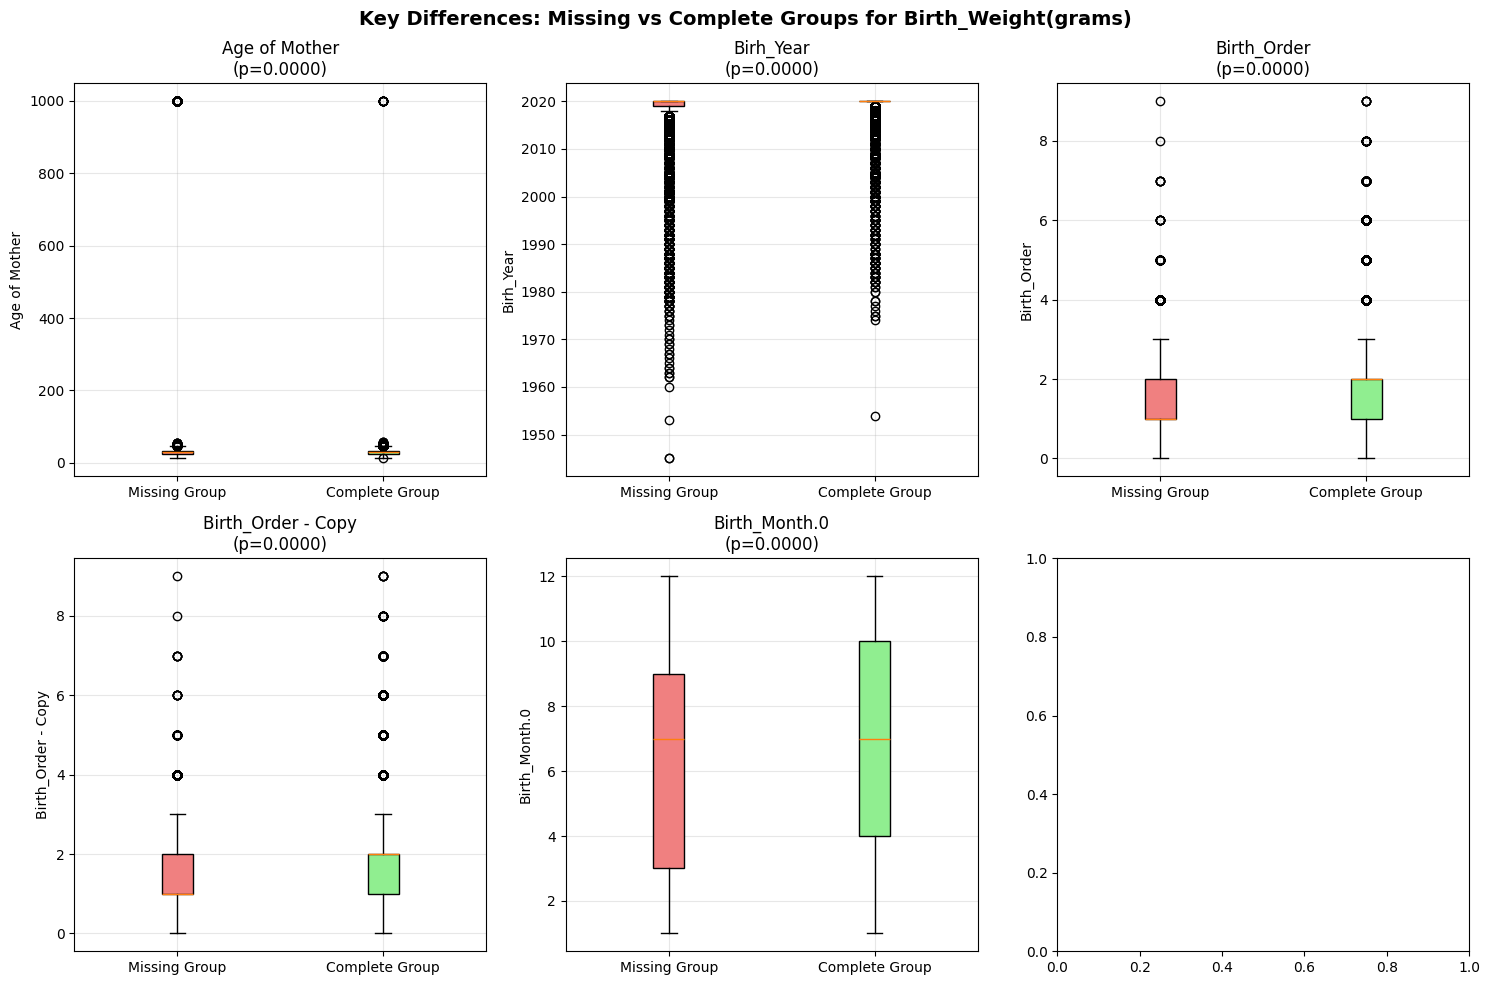

✅ Saved: Birth_Weight(grams)_bias_comparison.png

📋 BIAS ANALYSIS SUMMARY FOR 'Birth_Weight(grams)'

📊 MISSING DATA OVERVIEW:
   • Total records: 301,712
   • Missing Birth_Weight(grams): 33,542 (11.12%)
   • Complete Birth_Weight(grams): 268,170 (88.88%)

🔍 BIAS DETECTION RESULTS:
   • Total comparisons: 17
   • Significant bias detected: 16

📌 VARIABLES WITH SIGNIFICANT BIAS:
   • Registered_Month2.0 (Numeric): p=0.0189
   • Birh_Year (Numeric): p=0.0000
   • Birth_Month.0 (Numeric): p=0.0000
   • Birth_Order (Numeric): p=0.0000
   • Birth_Order - Copy (Numeric): p=0.0000
   • Age of Mother (Numeric): p=0.0000
   • Registered_Month (Categorical): p=0.0000
   • Registered_District (Categorical): p=0.0000
   • Birth_Month (Categorical): p=0.0000
   • Gender (Categorical): p=0.0052

📁 FILES CREATED:
   • missing_analysis_Birth_Weight(grams).xlsx - Complete dataset with missing and complete records
   • Birth_Weight(grams)_bias_comparison.png - Visualization of key differences

✅ ANALYSI

In [13]:



# ============================================
# FOCUS ON BIRTH WEIGHT - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Birth_Weight(grams)'  # <-- CHANGE THIS to analyze other variables
# ============================================

print(f"\n{'='*70}")
print(f"📊 MISSING DATA BIAS ANALYSIS FOR: '{TARGET_VARIABLE}'")
print(f"{'='*70}")

# Check if variable exists
if TARGET_VARIABLE not in df.columns:
    print(f"❌ ERROR: Variable '{TARGET_VARIABLE}' not found!")
    print(f"Available columns: {list(df.columns)[:20]}...")
    exit()

# Get missing info
missing_count = df[TARGET_VARIABLE].isnull().sum()
missing_pct = (missing_count / len(df)) * 100
complete_count = len(df) - missing_count
complete_pct = 100 - missing_pct

print(f"\n📌 BASIC INFORMATION:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Missing in {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete cases: {complete_count:,} ({complete_pct:.2f}%)")

# ============================================
# STEP 1: CREATE SEPARATE DATASETS
# ============================================

print(f"\n📌 STEP 1: CREATING SEPARATE DATASETS")
print("-" * 50)

# Dataset 1: Records with missing birth weight
missing_data = df[df[TARGET_VARIABLE].isnull()]

# Dataset 2: Records with complete birth weight
complete_data = df[df[TARGET_VARIABLE].notnull()]

print(f"   • Missing records: {len(missing_data):,}")
print(f"   • Complete records: {len(complete_data):,}")

# Save to Excel file
filename = f'missing_analysis_{TARGET_VARIABLE}.xlsx'

with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    # Sheet 1: All records with missing birth weight
    missing_data.to_excel(writer, sheet_name=f'Missing_{TARGET_VARIABLE}', index=False)
    
    # Sheet 2: All records with complete birth weight
    complete_data.to_excel(writer, sheet_name=f'Complete_{TARGET_VARIABLE}', index=False)
    
    # Sheet 3: Summary statistics
    summary = pd.DataFrame({
        'Metric': [
            'Variable Name',
            'Total Records',
            f'Missing in {TARGET_VARIABLE}',
            'Missing %',
            f'Complete {TARGET_VARIABLE}',
            'Complete %'
        ],
        'Value': [
            TARGET_VARIABLE,
            f"{len(df):,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            f"{complete_count:,}",
            f"{complete_pct:.2f}%"
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print(f"✅ Created: {filename}")

# ============================================
# STEP 2: COMPARE MISSING VS COMPLETE GROUPS
# ============================================

print(f"\n📌 STEP 2: BIAS ANALYSIS - COMPARING GROUPS")
print("-" * 70)

bias_results = []

# Compare NUMERIC variables
print(f"\n🔍 Comparing NUMERIC variables between groups:")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for num_col in numeric_cols:
    if num_col != TARGET_VARIABLE:
        # Get means for both groups (ignoring missing in the comparison variable)
        missing_mean = missing_data[num_col].mean()
        complete_mean = complete_data[num_col].mean()
        
        # Only compare if both groups have data
        if not np.isnan(missing_mean) and not np.isnan(complete_mean):
            # Statistical test
            try:
                t_stat, p_value = stats.ttest_ind(
                    missing_data[num_col].dropna(),
                    complete_data[num_col].dropna(),
                    equal_var=False
                )
                
                bias_detected = p_value < 0.05
                
                bias_results.append({
                    'Variable_Type': 'Numeric',
                    'Variable_Name': num_col,
                    'Missing_Group_Mean': f"{missing_mean:.2f}",
                    'Complete_Group_Mean': f"{complete_mean:.2f}",
                    'Difference': f"{missing_mean - complete_mean:.2f}",
                    'Difference_%': f"{((missing_mean - complete_mean) / complete_mean * 100):.1f}%" if complete_mean != 0 else "N/A",
                    'P_Value': f"{p_value:.4f}",
                    'Significant_Bias': 'YES' if bias_detected else 'NO'
                })
                
                if bias_detected:
                    print(f"   ⚠️  {num_col}:")
                    print(f"      Missing group: {missing_mean:.2f} vs Complete: {complete_mean:.2f}")
                    print(f"      Difference: {missing_mean - complete_mean:.2f} (p={p_value:.4f})")
            except:
                pass

# Compare CATEGORICAL variables
print(f"\n🔍 Comparing CATEGORICAL variables between groups:")

cat_cols = df.select_dtypes(include=['object', 'category']).columns

for cat_col in cat_cols:
    if cat_col != TARGET_VARIABLE:
        try:
            # Create contingency table
            missing_indicator = ['Missing' if x else 'Complete' for x in df[TARGET_VARIABLE].isnull()]
            contingency = pd.crosstab(
                pd.Series(missing_indicator, name='Group'),
                df[cat_col]
            )
            
            # Chi-square test
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
            
            bias_detected = p_value < 0.05
            
            # Get distributions
            missing_dist = missing_data[cat_col].value_counts(normalize=True).head(3)
            complete_dist = complete_data[cat_col].value_counts(normalize=True).head(3)
            
            bias_results.append({
                'Variable_Type': 'Categorical',
                'Variable_Name': cat_col,
                'Missing_Group_Mean': str(dict(missing_dist))[:50],
                'Complete_Group_Mean': str(dict(complete_dist))[:50],
                'Difference': 'N/A',
                'Difference_%': 'N/A',
                'P_Value': f"{p_value:.4f}",
                'Significant_Bias': 'YES' if bias_detected else 'NO'
            })
            
            if bias_detected:
                print(f"   ⚠️  {cat_col}: p={p_value:.4f} - Significant bias detected")
        except:
            pass

# ============================================
# STEP 3: ADD BIAS RESULTS TO EXCEL
# ============================================

print(f"\n📌 STEP 3: ADDING BIAS ANALYSIS TO EXCEL")
print("-" * 50)

# Add bias results to the Excel file
with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
    if bias_results:
        bias_df = pd.DataFrame(bias_results)
        bias_df = bias_df.sort_values('P_Value')
        bias_df.to_excel(writer, sheet_name='Bias_Analysis', index=False)
        print(f"   ✅ Added Bias Analysis sheet with {len(bias_df)} comparisons")

print(f"\n✅ Updated Excel file: {filename}")

# ============================================
# STEP 4: VISUALIZE KEY DIFFERENCES
# ============================================

print(f"\n📌 STEP 4: CREATING VISUALIZATIONS")
print("-" * 50)

# Select top 5 numeric variables with largest differences
numeric_bias = [r for r in bias_results if r['Variable_Type'] == 'Numeric' and r['Significant_Bias'] == 'YES']
numeric_bias = sorted(numeric_bias, key=lambda x: abs(float(x['Difference'])), reverse=True)[:5]

if numeric_bias:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, bias in enumerate(numeric_bias):
        if i < 5:
            var_name = bias['Variable_Name']
            
            # Create boxplot comparison
            data_to_plot = [
                missing_data[var_name].dropna(),
                complete_data[var_name].dropna()
            ]
            
            bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['Missing Group', 'Complete Group'])
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            axes[i].set_title(f'{var_name}\n(p={bias["P_Value"]})')
            axes[i].set_ylabel(var_name)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplot
    if len(numeric_bias) < 5:
        axes[5].axis('off')
    
    plt.suptitle(f'Key Differences: Missing vs Complete Groups for {TARGET_VARIABLE}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{TARGET_VARIABLE}_bias_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {TARGET_VARIABLE}_bias_comparison.png")

# ============================================
# STEP 5: SUMMARY REPORT
# ============================================

print(f"\n{'='*70}")
print(f"📋 BIAS ANALYSIS SUMMARY FOR '{TARGET_VARIABLE}'")
print(f"{'='*70}")

print(f"\n📊 MISSING DATA OVERVIEW:")
print(f"   • Total records: {len(df):,}")
print(f"   • Missing {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete {TARGET_VARIABLE}: {complete_count:,} ({complete_pct:.2f}%)")

print(f"\n🔍 BIAS DETECTION RESULTS:")
if bias_results:
    significant_bias = [r for r in bias_results if r['Significant_Bias'] == 'YES']
    print(f"   • Total comparisons: {len(bias_results)}")
    print(f"   • Significant bias detected: {len(significant_bias)}")
    
    if significant_bias:
        print(f"\n📌 VARIABLES WITH SIGNIFICANT BIAS:")
        for bias in significant_bias[:10]:  # Show top 10
            print(f"   • {bias['Variable_Name']} ({bias['Variable_Type']}): p={bias['P_Value']}")
else:
    print(f"   • No bias comparisons could be performed")

print(f"\n📁 FILES CREATED:")
print(f"   • {filename} - Complete dataset with missing and complete records")
if numeric_bias:
    print(f"   • {TARGET_VARIABLE}_bias_comparison.png - Visualization of key differences")

print(f"\n{'='*70}")
print(f"✅ ANALYSIS COMPLETE")
print(f"{'='*70}")  # <-- FIXED: removed the '=' inside the f-string

# ============================================
# STEP 6: QUICK RECOMMENDATIONS
# ============================================

print(f"\n📋 RECOMMENDATIONS FOR '{TARGET_VARIABLE}':")
print("-" * 50)

if missing_pct < 1:
    print(f"✅ Very few missing ({missing_pct:.1f}%) - Can drop rows or use simple imputation")
elif missing_pct < 5:
    print(f"🟡 Some missing ({missing_pct:.1f}%) - Imputation recommended")
    if significant_bias:
        print(f"   ⚠️  But bias detected - consider keeping missing indicator")
elif missing_pct < 20:
    print(f"🟠 Moderate missing ({missing_pct:.1f}%) - Careful handling needed")
    if significant_bias:
        print(f"   ⚠️  Bias detected - missingness may be informative")
    else:
        print(f"   ✅ No significant bias - imputation may be safe")
elif missing_pct < 50:
    print(f"🔴 High missing ({missing_pct:.1f}%) - Consider dropping or creating missing category")
else:
    print(f"⚫ Very high missing ({missing_pct:.1f}%) - Likely drop this variable")


🔍 ANALYZING PATTERNS WITHIN MISSING BIRTH WEIGHT RECORDS

📊 ANALYZING 33,542 RECORDS WITH MISSING BIRTH WEIGHT

📌 STEP 1: CLUSTERING ANALYSIS - FINDING NATURAL GROUPINGS
----------------------------------------------------------------------
   Found 8 numeric columns and 10 categorical columns
   Using 8 numeric and 10 categorical features

📌 STEP 2: PREPARING DATA FOR CLUSTERING
----------------------------------------------------------------------
   Processing 8 numeric features...
   Found 7 numeric features with data
   ✅ Added 7 scaled numeric features

   Processing 10 categorical features...
      • Encoded Registered_Month (12 categories)
      • Encoded Registered_District (25 categories)
      • Encoded Birth_Month (12 categories)
      • Encoded Gender (3 categories)
      • Encoded Hospital or Not (2 categories)
      • Encoded Multiple_Birth_Status (5 categories)
      • Encoded Marital_Status (3 categories)
      • Encoded District_of_Mother (27 categories)
      • Enco

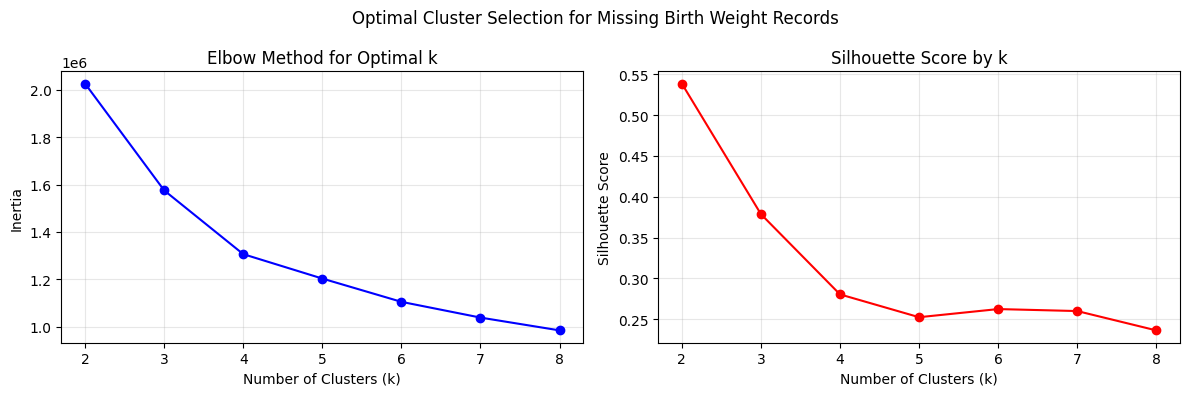


✅ Optimal number of clusters: 2

📌 STEP 4: ANALYZING CLUSTER CHARACTERISTICS
----------------------------------------------------------------------

📍 CLUSTER 0: 26218 records (78.2%)
   Key distinguishing characteristics:
      • Registered_Month: most common is 'September' (12.1%)
      • Registered_District: most common is 'Batticaloa' (29.2%)
      • Birth_Month: most common is 'August' (10.6%)
      • Gender: most common is 'Male' (50.3%)
      • Hospital or Not: most common is 'Hospital' (99.2%)

📍 CLUSTER 1: 7324 records (21.8%)
   Key distinguishing characteristics:
      • Registered_Month: most common is 'August' (20.4%)
      • Registered_District: most common is 'Kurunagala' (16.0%)
      • Birth_Month: most common is 'July' (12.1%)
      • Gender: most common is 'Male' (51.3%)
      • Hospital or Not: most common is 'Hospital' (97.0%)

📌 STEP 5: VISUALIZING CLUSTERS
----------------------------------------------------------------------


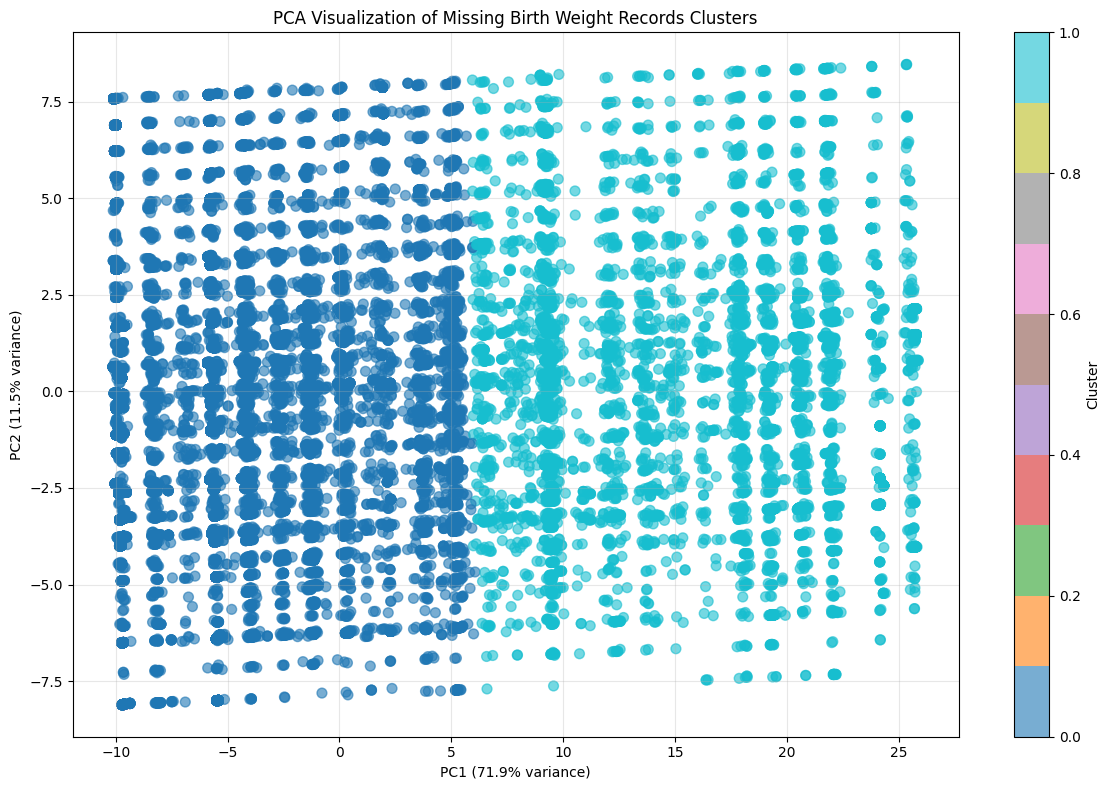


📌 STEP 6: CREATING SUMMARY REPORT
----------------------------------------------------------------------
✅ Saved: missing_birthweight_clusters.xlsx with cluster assignments

📋 PATTERN ANALYSIS SUMMARY

🔍 KEY FINDINGS:
   • 33,542 records analyzed for patterns
   • Identified 2 distinct clusters/patterns

📊 CLUSTER DISTRIBUTION:
   • Cluster 0: 26218 records (78.2%)
   • Cluster 1: 7324 records (21.8%)

🎯 INTERPRETATION FOR MANUAL DATA ENTRY:
--------------------------------------------------
✅ MULTIPLE PATTERNS DETECTED
   This suggests missing birth weight follows specific patterns
   Different groups of records show different characteristics

   🔍 SUGGESTION: The patterns are clear and manageable
      Review each cluster's characteristics to identify
      the specific reason for each pattern

📁 FILES GENERATED:
   • missing_data_clustering_elbow.png - Cluster selection plot
   • missing_data_clusters_pca.png - Cluster visualization
   • missing_birthweight_clusters.xlsx - Data wit

In [17]:
# ============================================
# ANALYSIS OF SIMILARITIES WITHIN MISSING BIRTH WEIGHT RECORDS
# ============================================

print(f"\n{'='*70}")
print(f"🔍 ANALYZING PATTERNS WITHIN MISSING BIRTH WEIGHT RECORDS")
print(f"{'='*70}")

# Load the missing data we created earlier
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()

print(f"\n📊 ANALYZING {len(missing_data):,} RECORDS WITH MISSING BIRTH WEIGHT")

# ============================================
# 1. CLUSTERING ANALYSIS TO FIND NATURAL GROUPINGS
# ============================================

print(f"\n📌 STEP 1: CLUSTERING ANALYSIS - FINDING NATURAL GROUPINGS")
print("-" * 70)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Prepare data for clustering
cluster_data = missing_data.copy()

# Separate numeric and categorical columns
numeric_cols = cluster_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = cluster_data.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"   Found {len(numeric_cols)} numeric columns and {len(categorical_cols)} categorical columns")

# Select features for clustering (excluding identifiers)
exclude_patterns = ['ID', 'id', 'Name', 'name', 'Patient', 'Date', 'date', 'Time', 'time']
numeric_features = [col for col in numeric_cols if not any(pattern in col for pattern in exclude_patterns)]
categorical_features = [col for col in categorical_cols if not any(pattern in col for pattern in exclude_patterns)]

print(f"   Using {len(numeric_features)} numeric and {len(categorical_features)} categorical features")

# ============================================
# 2. PREPARE DATA FOR CLUSTERING
# ============================================

print(f"\n📌 STEP 2: PREPARING DATA FOR CLUSTERING")
print("-" * 70)

encoded_data = pd.DataFrame(index=cluster_data.index)

# Handle numeric columns carefully
if numeric_features:
    print(f"   Processing {len(numeric_features)} numeric features...")
    
    # First, check which numeric columns actually have data
    valid_numeric_features = []
    for col in numeric_features:
        if cluster_data[col].notna().sum() > 0:  # Column has at least one non-null value
            valid_numeric_features.append(col)
    
    print(f"   Found {len(valid_numeric_features)} numeric features with data")
    
    if valid_numeric_features:
        # Create numeric data array
        numeric_data_list = []
        valid_columns = []
        
        for col in valid_numeric_features:
            col_data = cluster_data[col].fillna(cluster_data[col].median()).values.reshape(-1, 1)
            numeric_data_list.append(col_data)
            valid_columns.append(col)
        
        if numeric_data_list:
            # Combine all numeric columns
            numeric_array = np.hstack(numeric_data_list)
            
            # Scale numeric data
            scaler = StandardScaler()
            scaled_numeric = scaler.fit_transform(numeric_array)
            
            # Add to encoded data with original column names
            for i, col in enumerate(valid_columns):
                encoded_data[col] = scaled_numeric[:, i]
            
            print(f"   ✅ Added {len(valid_columns)} scaled numeric features")
else:
    valid_numeric_features = []
    print("   No numeric features found")

# Handle categorical columns
if categorical_features:
    print(f"\n   Processing {len(categorical_features)} categorical features...")
    
    valid_categorical_features = []
    for col in categorical_features:
        if cluster_data[col].nunique() > 1:  # Column has variation
            # Fill missing with 'MISSING' and encode
            non_null = cluster_data[col].fillna('MISSING').astype(str)
            
            # Only use if not too many unique values
            if non_null.nunique() <= 50:  # Limit to reasonable number of categories
                le = LabelEncoder()
                encoded_data[f'{col}'] = le.fit_transform(non_null)
                valid_categorical_features.append(col)
                print(f"      • Encoded {col} ({non_null.nunique()} categories)")
            else:
                print(f"      • Skipped {col} (too many categories: {non_null.nunique()})")
    
    print(f"   ✅ Added {len(valid_categorical_features)} encoded categorical features")
else:
    valid_categorical_features = []
    print("   No categorical features found")

# Check if we have data for clustering
if len(encoded_data.columns) == 0:
    print("❌ ERROR: No suitable features for clustering!")
    print("   Trying alternative approach with basic features...")
    
    # Alternative: use any numeric columns that exist
    basic_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] 
                     and col != TARGET_VARIABLE
                     and 'ID' not in col and 'id' not in col][:5]
    
    if basic_features:
        for col in basic_features:
            if col in missing_data.columns:
                encoded_data[col] = missing_data[col].fillna(missing_data[col].median())
        
        # Scale the basic features
        scaler = StandardScaler()
        scaled_basic = scaler.fit_transform(encoded_data)
        encoded_data = pd.DataFrame(scaled_basic, columns=encoded_data.columns, index=encoded_data.index)
        print(f"   ✅ Using {len(basic_features)} basic features for clustering")
    else:
        print("❌ No features available for clustering")
        exit()

print(f"\n📊 Final feature set: {encoded_data.shape[1]} features for {len(encoded_data)} records")
print(f"   Features: {', '.join(encoded_data.columns[:10])}")

# Remove any rows with NaN or infinite values
encoded_data = encoded_data.replace([np.inf, -np.inf], np.nan)
encoded_data = encoded_data.dropna()
print(f"   After cleaning: {len(encoded_data)} records available for clustering")

if len(encoded_data) < 10:
    print("❌ Too few records for clustering after cleaning")
    exit()

# ============================================
# 3. PERFORM CLUSTERING
# ============================================

print(f"\n📌 STEP 3: PERFORMING CLUSTERING ANALYSIS")
print("-" * 70)

# Find optimal number of clusters
max_clusters = min(8, len(encoded_data) // 20 + 2)
if max_clusters < 2:
    max_clusters = 2

K_range = range(2, max_clusters + 1)
inertias = []
silhouette_scores = []

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(encoded_data)
    inertias.append(kmeans.inertia_)
    if len(set(labels)) > 1:
        try:
            score = silhouette_score(encoded_data, labels)
            silhouette_scores.append(score)
        except:
            silhouette_scores.append(-1)
    else:
        silhouette_scores.append(-1)

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimal Cluster Selection for Missing Birth Weight Records')
plt.tight_layout()
plt.savefig('missing_data_clustering_elbow.png', dpi=300, bbox_inches='tight')
plt.show()

# Choose optimal k (best silhouette score)
if max(silhouette_scores) > 0:
    optimal_k = K_range[np.argmax(silhouette_scores)]
else:
    optimal_k = 2  # Default to 2 clusters if silhouette scores are bad

print(f"\n✅ Optimal number of clusters: {optimal_k}")

# Perform final clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
missing_data_aligned = missing_data.loc[encoded_data.index]  # Align indices
missing_data_aligned['Cluster'] = kmeans.fit_predict(encoded_data)

# ============================================
# 4. ANALYZE EACH CLUSTER'S CHARACTERISTICS
# ============================================

print(f"\n📌 STEP 4: ANALYZING CLUSTER CHARACTERISTICS")
print("-" * 70)

cluster_summary = pd.DataFrame()

for cluster in range(optimal_k):
    cluster_records = missing_data_aligned[missing_data_aligned['Cluster'] == cluster]
    print(f"\n📍 CLUSTER {cluster}: {len(cluster_records)} records ({len(cluster_records)/len(missing_data_aligned)*100:.1f}%)")
    
    print(f"   Key distinguishing characteristics:")
    char_count = 0
    
    # Analyze numeric features
    for col in valid_numeric_features[:5]:  # Limit to top 5 numeric
        if col in cluster_records.columns:
            cluster_mean = cluster_records[col].mean()
            overall_mean = missing_data_aligned[col].mean()
            cluster_std = cluster_records[col].std()
            
            if pd.notna(cluster_mean) and pd.notna(overall_mean) and overall_mean != 0:
                diff_pct = ((cluster_mean - overall_mean) / abs(overall_mean)) * 100
                if abs(diff_pct) > 20:  # Show if >20% different
                    print(f"      • {col}: {cluster_mean:.2f} ± {cluster_std:.2f} vs overall {overall_mean:.2f} ({diff_pct:+.1f}%)")
                    char_count += 1
    
    # Analyze categorical features
    for col in valid_categorical_features[:5]:  # Limit to top 5 categorical
        if col in cluster_records.columns:
            # Get top category in this cluster
            cluster_top = cluster_records[col].value_counts()
            if len(cluster_top) > 0:
                cluster_top_cat = cluster_top.index[0]
                cluster_top_pct = (cluster_top.iloc[0] / len(cluster_records)) * 100
                
                # Get original value (decode if needed)
                if isinstance(cluster_top_cat, (int, np.integer)):
                    # Try to get original category if we encoded it
                    original_val = 'Unknown'
                else:
                    original_val = cluster_top_cat
                
                print(f"      • {col}: most common is '{original_val}' ({cluster_top_pct:.1f}%)")
                char_count += 1
    
    if char_count == 0:
        print(f"      • No strongly distinguishing characteristics found")

# ============================================
# 5. VISUALIZE CLUSTERS
# ============================================

print(f"\n📌 STEP 5: VISUALIZING CLUSTERS")
print("-" * 70)

# PCA for visualization
n_components = min(2, encoded_data.shape[1])
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(encoded_data)

# Create cluster visualization
plt.figure(figsize=(12, 8))

if pca_result.shape[1] >= 2:
    # Scatter plot with clusters
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                         c=missing_data_aligned['Cluster'], cmap='tab10', 
                         alpha=0.6, s=50)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
else:
    # If only 1 component, plot against index
    scatter = plt.scatter(range(len(pca_result)), pca_result[:, 0], 
                         c=missing_data_aligned['Cluster'], cmap='tab10', 
                         alpha=0.6, s=50)
    plt.xlabel('Record Index')
    plt.ylabel('PC1')

plt.title('PCA Visualization of Missing Birth Weight Records Clusters')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('missing_data_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. CREATE SUMMARY REPORT
# ============================================

print(f"\n📌 STEP 6: CREATING SUMMARY REPORT")
print("-" * 70)

# Save cluster assignments
output_file = 'missing_birthweight_clusters.xlsx'
missing_data_aligned.to_excel(output_file, index=False)
print(f"✅ Saved: {output_file} with cluster assignments")

# Create simple text summary
print(f"\n{'='*70}")
print(f"📋 PATTERN ANALYSIS SUMMARY")
print(f"{'='*70}")

print(f"\n🔍 KEY FINDINGS:")
print(f"   • {len(missing_data_aligned):,} records analyzed for patterns")
print(f"   • Identified {optimal_k} distinct clusters/patterns")

print(f"\n📊 CLUSTER DISTRIBUTION:")
for cluster in range(optimal_k):
    size = len(missing_data_aligned[missing_data_aligned['Cluster'] == cluster])
    pct = (size/len(missing_data_aligned))*100
    print(f"   • Cluster {cluster}: {size} records ({pct:.1f}%)")

print(f"\n🎯 INTERPRETATION FOR MANUAL DATA ENTRY:")
print("-" * 50)

if optimal_k > 1:
    print(f"✅ MULTIPLE PATTERNS DETECTED")
    print(f"   This suggests missing birth weight follows specific patterns")
    print(f"   Different groups of records show different characteristics")
    
    if optimal_k <= 3:
        print(f"\n   🔍 SUGGESTION: The patterns are clear and manageable")
        print(f"      Review each cluster's characteristics to identify")
        print(f"      the specific reason for each pattern")
    else:
        print(f"\n   🔍 SUGGESTION: Multiple patterns detected - consider if")
        print(f"      they correspond to different time periods, locations,")
        print(f"      or data entry personnel")
else:
    print(f"⚠️ SINGLE PATTERN DETECTED")
    print(f"   Missingness appears uniform across records")
    print(f"   May be random or consistently missing for all cases")

print(f"\n📁 FILES GENERATED:")
print(f"   • missing_data_clustering_elbow.png - Cluster selection plot")
print(f"   • missing_data_clusters_pca.png - Cluster visualization")
print(f"   • missing_birthweight_clusters.xlsx - Data with cluster assignments")

print(f"\n{'='*70}")
print(f"✅ PATTERN ANALYSIS COMPLETE")
print(f"{'='*70}")

# ============================================
# 7. NEXT STEPS
# ============================================

print(f"\n📋 RECOMMENDED NEXT STEPS:")
print("-" * 50)

print(f"\n1. REVIEW THE CLUSTERS:")
print(f"   • Open 'missing_birthweight_clusters.xlsx'")
print(f"   • Look at each cluster's records - what do they have in common?")

print(f"\n2. CHECK FOR TEMPORAL PATTERNS:")
print(f"   • If you have date fields, check if clusters correspond to specific time periods")

print(f"\n3. VERIFY WITH DATA ENTRY STAFF:")
print(f"   • Share the patterns with people who entered the data")
print(f"   • Ask if they recognize these groupings")

print(f"\n4. DECISION FOR ANALYSIS:")
if optimal_k > 1:
    print(f"   • Since clear patterns exist, consider keeping 'missing' as a separate category")
    print(f"   • Or analyze each cluster separately if they represent meaningful groups")
else:
    print(f"   • Since no strong patterns, simple imputation may be acceptable")

print(f"\n{'='*70}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT RECORDS

📌 DATASET OVERVIEW:
   • Total records with missing birth weight: 33,542
   • Total records with complete birth weight: 268,170

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS

🔍 CORRELATION MATRIX (Numeric Variables):

   Strong Correlations Found:
   • Birth_Order & Birth_Order - Copy: 1.000 (Very Strong)

🔍 CATEGORICAL ASSOCIATIONS:
   • Registered_Month & Registered_District: p=0.0000, Cramer's V=0.212
   • Registered_Month & Birth_Month: p=0.0000, Cramer's V=0.393
   • Registered_Month & Hospital or Not: p=0.0000, Cramer's V=0.037
   • Registered_District & Birth_Month: p=0.0000, Cramer's V=0.136
   • Registered_District & Gender: p=0.0000, Cramer's V=0.038
   • Registered_District & Hospital or Not: p=0.0000, Cramer's V=0.232

📌 PART 3: MISSINGNESS PATTERN ANALYSIS

🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:
   • Birth_Order

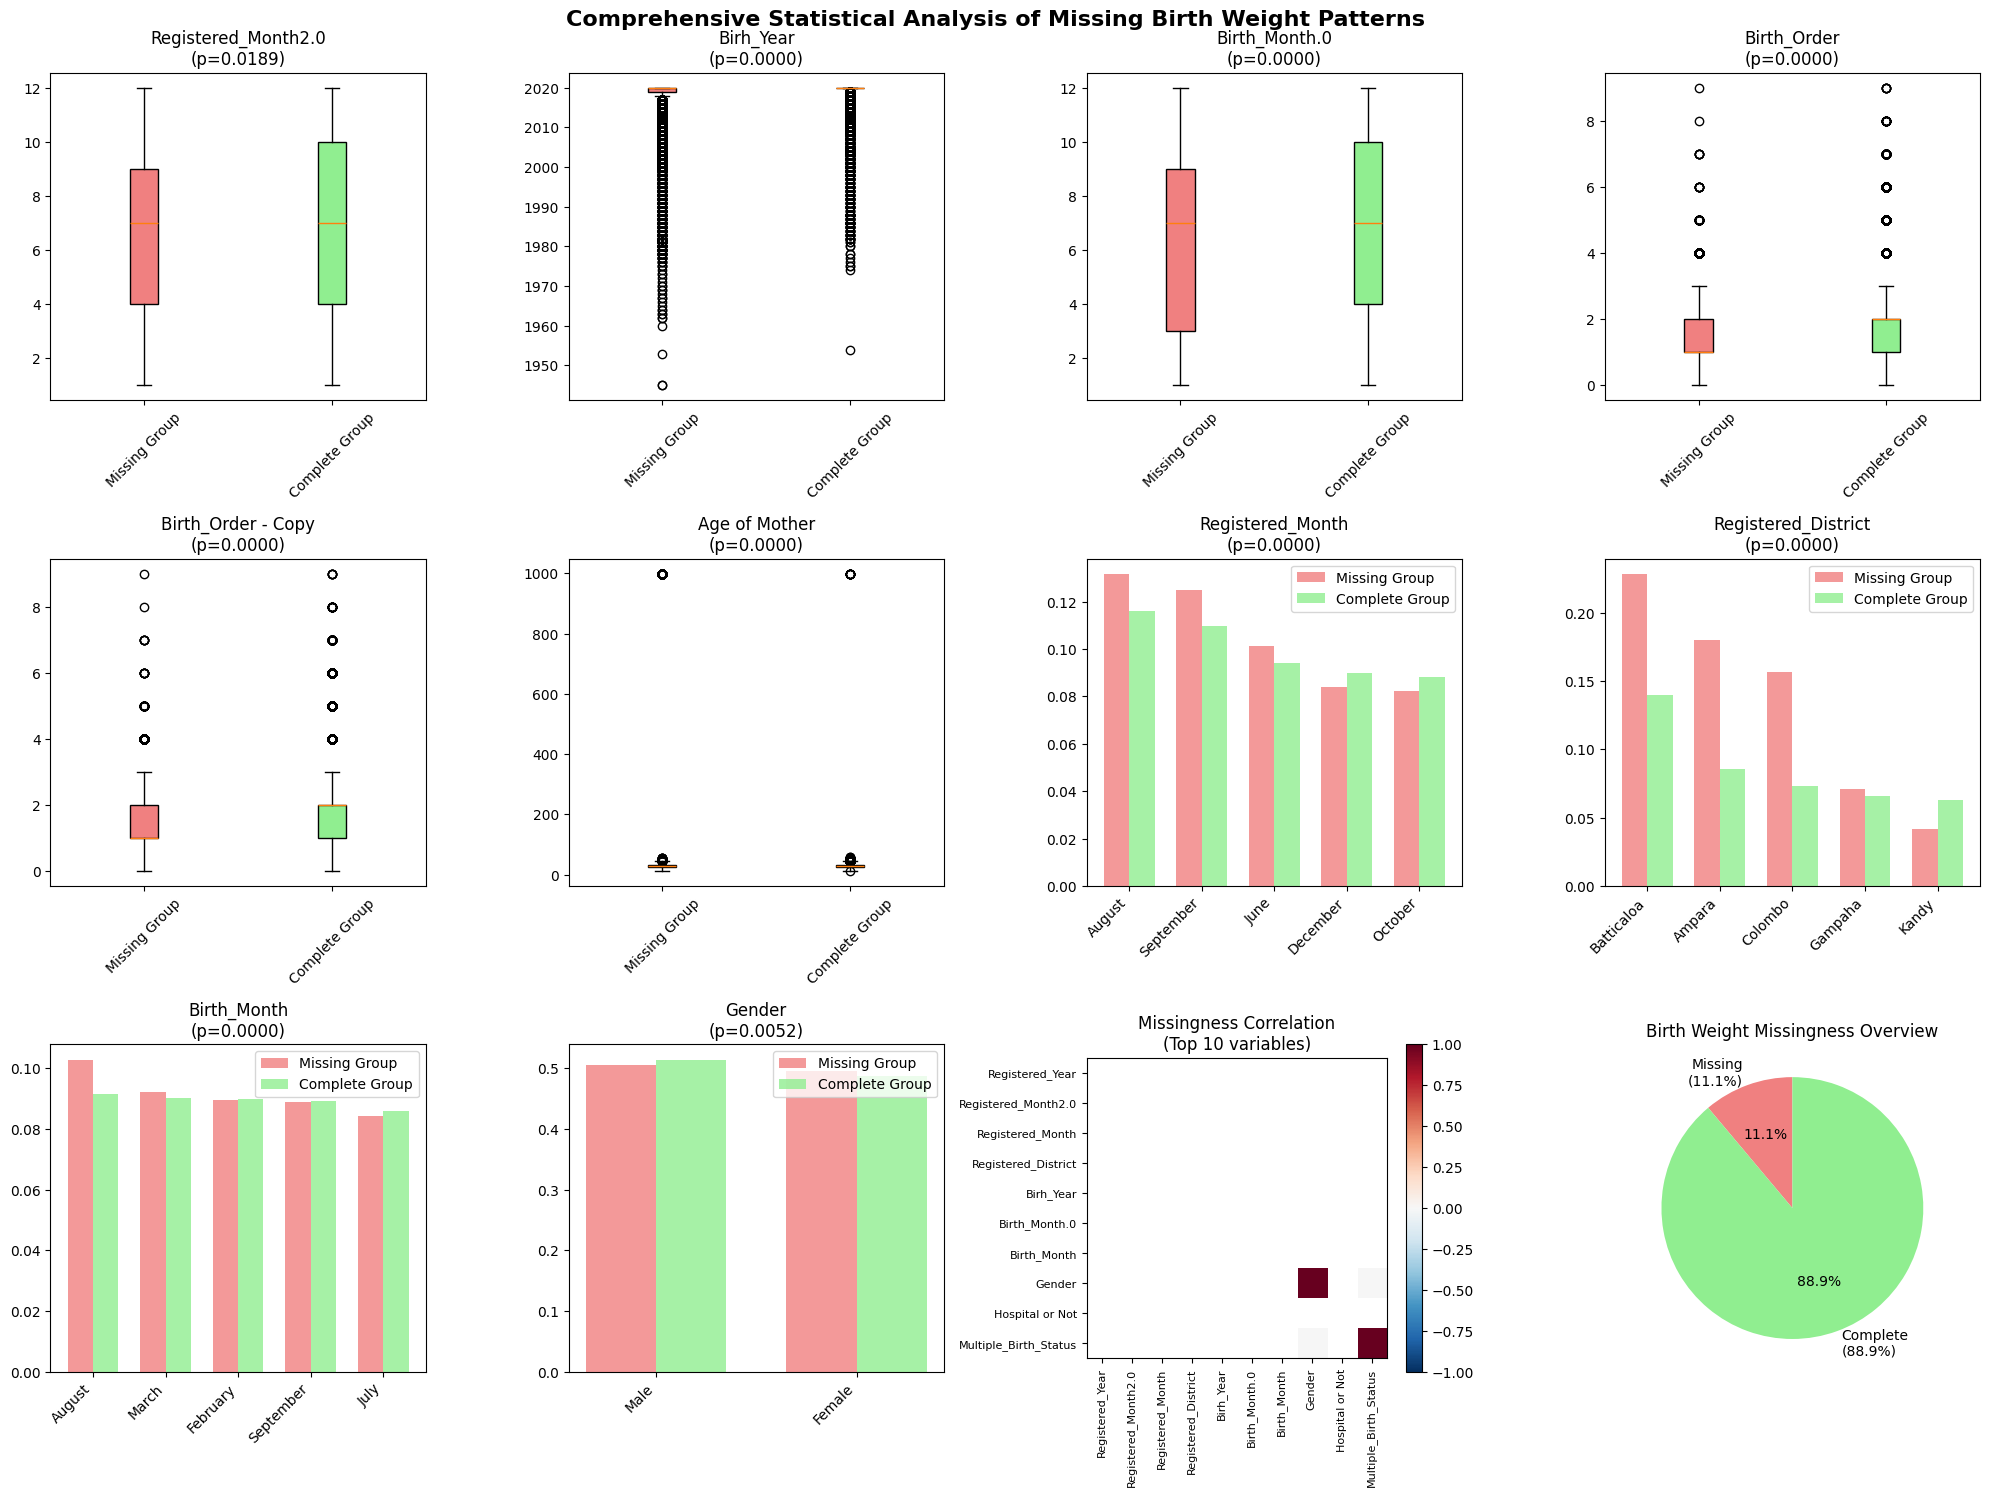


📋 COMPREHENSIVE STATISTICAL SUMMARY

📊 OVERALL STATISTICS:
   • Total missing birth weight records: 33,542 (11.1% of total)
   • Number of variables analyzed: 18
   • Numeric variables: 8
   • Categorical variables: 10

🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):
   • Registered_Month2.0: Mean=6.80 vs Complete Mean (diff: 0.05, p=0.0189)
   • Registered_Month: Most common='August' (13.2%), p=0.0000
   • Registered_District: Most common='Batticaloa' (22.8%), p=0.0000
   • Birh_Year: Mean=2018.30 vs Complete Mean (diff: -1.51, p=0.0000)
   • Birth_Month.0: Mean=6.42 vs Complete Mean (diff: -0.18, p=0.0000)
   • Birth_Month: Most common='August' (10.3%), p=0.0000
   • Gender: Most common='Male' (50.5%), p=0.0052
   • Hospital or Not: Most common='Hospital' (98.7%), p=0.0000
   • Multiple_Birth_Status: Most common='missing' (99.4%), p=0.0000
   • Birth_Order: Mean=1.37 vs Complete Mean (diff: -0.50, p=0.0000)
   • Birth_Order - Copy: Mean=1.37 vs Complete Mean (diff: -0.50, p=0.0

In [30]:
# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# ============================================

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT RECORDS")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing birth weight: {len(missing_data):,}")
print(f"   • Total records with complete birth weight: {len(complete_data):,}")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []

# Analyze each column in the missing data
for col in missing_data.columns:
    if col == TARGET_VARIABLE:
        continue
        
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Statistics based on data type
    if missing_data[col].dtype in ['int64', 'float64']:
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            # Central tendency
            col_stats.update({
                'Mean': valid_data.mean(),
                'Median': valid_data.median(),
                'Mode': valid_data.mode().iloc[0] if len(valid_data.mode()) > 0 else np.nan,
                'Std_Dev': valid_data.std(),
                'Variance': valid_data.var(),
                'Min': valid_data.min(),
                'Max': valid_data.max(),
                'Range': valid_data.max() - valid_data.min(),
                'Q1': valid_data.quantile(0.25),
                'Q3': valid_data.quantile(0.75),
                'IQR': valid_data.quantile(0.75) - valid_data.quantile(0.25),
                'Skewness': valid_data.skew(),
                'Kurtosis': valid_data.kurtosis(),
            })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                from scipy import stats
                t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                col_stats['T_Test_P_Value'] = p_value
                col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                col_stats['Effect_Size'] = (valid_data.mean() - complete_valid_data.mean()) / complete_valid_data.std() if complete_valid_data.std() > 0 else 0
                col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                col_stats['Mean_Difference_%'] = ((valid_data.mean() - complete_valid_data.mean()) / complete_valid_data.mean()) * 100 if complete_valid_data.mean() != 0 else np.nan
            else:
                col_stats['T_Test_P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Effect_Size'] = np.nan
                col_stats['Mean_Difference'] = np.nan
                col_stats['Mean_Difference_%'] = np.nan
        else:
            # No valid data in missing group
            col_stats.update({
                'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan,
                'T_Test_P_Value': np.nan, 'Significant_Difference': 'N/A', 'Effect_Size': np.nan,
                'Mean_Difference': np.nan, 'Mean_Difference_%': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': top_categories.index[0] if len(top_categories) > 0 else np.nan,
                'Most_Common_Count': top_categories.iloc[0] if len(top_categories) > 0 else 0,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': top_categories.index[1] if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': top_categories.index[2] if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
                'Entropy': stats.entropy(value_counts.values) if len(value_counts) > 1 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    # Create contingency table
                    missing_cats = valid_data.value_counts()
                    complete_cats = complete_valid.value_counts()
                    
                    # Align categories
                    all_cats = set(missing_cats.index) | set(complete_cats.index)
                    missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                    complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                    
                    # Chi-square test
                    contingency = np.array([missing_counts, complete_counts])
                    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                    
                    col_stats['Chi_Square_P_Value'] = p_value
                    col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                    col_stats['Cramers_V'] = np.sqrt(chi2 / (len(valid_data) + len(complete_valid)))
                else:
                    col_stats['Chi_Square_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
                    col_stats['Cramers_V'] = np.nan
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_Count': 0, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'Entropy': 0, 'Chi_Square_P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Cramers_V': np.nan
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# ============================================
# 2. MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS")
print(f"{'='*80}")

# Correlation matrix for numeric variables
numeric_vars = missing_data.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_vars) > 1:
    print(f"\n🔍 CORRELATION MATRIX (Numeric Variables):")
    
    # Calculate correlations
    corr_matrix = missing_data[numeric_vars].corr()
    
    # Find strong correlations
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.5:  # Strong correlation threshold
                strong_corrs.append({
                    'Variable_1': corr_matrix.columns[i],
                    'Variable_2': corr_matrix.columns[j],
                    'Correlation': corr_value,
                    'Strength': 'Very Strong' if abs(corr_value) > 0.8 else 'Strong'
                })
    
    if strong_corrs:
        print("\n   Strong Correlations Found:")
        for corr in strong_corrs:
            print(f"   • {corr['Variable_1']} & {corr['Variable_2']}: {corr['Correlation']:.3f} ({corr['Strength']})")
    else:
        print("\n   No strong correlations found between numeric variables")

# Association for categorical variables
categorical_vars = missing_data.select_dtypes(include=['object', 'category']).columns
if len(categorical_vars) > 1:
    print(f"\n🔍 CATEGORICAL ASSOCIATIONS:")
    
    from scipy.stats import chi2_contingency
    
    for i in range(min(5, len(categorical_vars))):
        for j in range(i+1, min(5, len(categorical_vars))):
            var1, var2 = categorical_vars[i], categorical_vars[j]
            
            # Create contingency table
            contingency = pd.crosstab(missing_data[var1].fillna('MISSING'), 
                                     missing_data[var2].fillna('MISSING'))
            
            if contingency.size > 0:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                if p_value < 0.05:
                    cramer_v = np.sqrt(chi2 / (len(missing_data) * (min(contingency.shape) - 1)))
                    print(f"   • {var1} & {var2}: p={p_value:.4f}, Cramer's V={cramer_v:.3f}")

# ============================================
# 3. MISSINGNESS PATTERN ANALYSIS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: MISSINGNESS PATTERN ANALYSIS")
print(f"{'='*80}")

# Create missingness matrix
missing_matrix = missing_data.isnull()

# Calculate missingness correlation
missing_corr = missing_matrix.corr()

print(f"\n🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:")
high_missing_corr = []
for i in range(len(missing_corr.columns)):
    for j in range(i+1, len(missing_corr.columns)):
        if abs(missing_corr.iloc[i, j]) > 0.3:
            high_missing_corr.append({
                'Var1': missing_corr.columns[i],
                'Var2': missing_corr.columns[j],
                'Correlation': missing_corr.iloc[i, j]
            })

if high_missing_corr:
    for item in sorted(high_missing_corr, key=lambda x: abs(x['Correlation']), reverse=True)[:10]:
        print(f"   • {item['Var1']} & {item['Var2']}: {item['Correlation']:.3f}")
else:
    print("   No strong missingness correlations found")

# ============================================
# 4. CREATE COMPREHENSIVE EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING COMPREHENSIVE STATISTICAL REPORT")
print(f"{'='*80}")

output_file = 'missing_birthweight_comprehensive_stats.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    
    # Sheet 1: Variable-level Statistics
    stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
    
    # Sheet 2: Summary Statistics
    summary_stats = pd.DataFrame({
        'Metric': ['Total Missing Records', 'Total Variables', 'Numeric Variables', 'Categorical Variables'],
        'Value': [
            len(missing_data),
            len(missing_data.columns),
            len(numeric_vars),
            len(categorical_vars)
        ]
    })
    summary_stats.to_excel(writer, sheet_name='Summary', index=False)
    
    # Sheet 3: Variables with Significant Differences
    sig_diff = stats_df[stats_df['Significant_Difference'] == 'YES']
    if not sig_diff.empty:
        sig_diff.to_excel(writer, sheet_name='Significant_Differences', index=False)
    
    # Sheet 4: Missingness Correlation
    missing_corr.to_excel(writer, sheet_name='Missing_Correlations')
    
    # Sheet 5: Numeric Correlations
    if len(numeric_vars) > 1:
        corr_matrix.to_excel(writer, sheet_name='Numeric_Correlations')
    
    # Sheet 6: Frequency Tables for Key Categorical Variables
    for cat_var in categorical_vars[:5]:  # Limit to first 5
        if missing_data[cat_var].notna().sum() > 0:
            freq_table = pd.DataFrame({
                'Category': missing_data[cat_var].value_counts().index,
                'Count': missing_data[cat_var].value_counts().values,
                'Percentage': (missing_data[cat_var].value_counts().values / len(missing_data)) * 100
            })
            sheet_name = f'Freq_{cat_var[:20]}'  # Limit sheet name length
            freq_table.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"✅ Created comprehensive statistical report: {output_file}")

# ============================================
# 5. VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 5: CREATING STATISTICAL VISUALIZATIONS")
print(f"{'='*80}")

# Create a multi-panel figure
fig = plt.figure(figsize=(20, 15))

# 1. Box plots for numeric variables with significant differences
sig_numeric = stats_df[(stats_df['Data_Type'].str.contains('int|float')) & 
                       (stats_df['Significant_Difference'] == 'YES')].head(6)

if len(sig_numeric) > 0:
    for i, (idx, row) in enumerate(sig_numeric.iterrows()):
        if i < 6:
            ax = plt.subplot(3, 4, i+1)
            var_name = row['Variable']
            
            if var_name in missing_data.columns and var_name in complete_data.columns:
                missing_vals = missing_data[var_name].dropna()
                complete_vals = complete_data[var_name].dropna()
                
                if len(missing_vals) > 0 and len(complete_vals) > 0:
                    bp = ax.boxplot([missing_vals, complete_vals], 
                                   labels=['Missing Group', 'Complete Group'],
                                   patch_artist=True)
                    bp['boxes'][0].set_facecolor('lightcoral')
                    bp['boxes'][1].set_facecolor('lightgreen')
                    ax.set_title(f'{var_name}\n(p={row["T_Test_P_Value"]:.4f})')
                    ax.tick_params(axis='x', rotation=45)

# 2. Bar plots for categorical variables with significant differences
sig_cat = stats_df[(~stats_df['Data_Type'].str.contains('int|float')) & 
                   (stats_df['Significant_Difference'] == 'YES')].head(4)

for i, (idx, row) in enumerate(sig_cat.iterrows()):
    if i < 4:
        ax = plt.subplot(3, 4, 7+i)
        var_name = row['Variable']
        
        if var_name in missing_data.columns:
            missing_dist = missing_data[var_name].value_counts(normalize=True).head(5)
            complete_dist = complete_data[var_name].value_counts(normalize=True).head(5)
            
            x = range(len(missing_dist))
            width = 0.35
            
            ax.bar([i - width/2 for i in x], missing_dist.values, width, label='Missing Group', color='lightcoral', alpha=0.8)
            ax.bar([i + width/2 for i in x], complete_dist.values[:len(missing_dist)], width, label='Complete Group', color='lightgreen', alpha=0.8)
            
            ax.set_title(f'{var_name}\n(p={row["Chi_Square_P_Value"]:.4f})')
            ax.set_xticks(x)
            ax.set_xticklabels(missing_dist.index, rotation=45, ha='right')
            ax.legend()

# 3. Missingness correlation heatmap
if len(missing_corr.columns) > 1:
    ax = plt.subplot(3, 4, 11)
    im = ax.imshow(missing_corr.values[:10, :10], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(min(10, len(missing_corr.columns))))
    ax.set_yticks(range(min(10, len(missing_corr.columns))))
    ax.set_xticklabels(missing_corr.columns[:10], rotation=90, fontsize=8)
    ax.set_yticklabels(missing_corr.columns[:10], fontsize=8)
    ax.set_title('Missingness Correlation\n(Top 10 variables)')
    plt.colorbar(im, ax=ax)

# 4. Missing data overview pie chart
ax = plt.subplot(3, 4, 12)
missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
ax.pie([missing_pct, complete_pct], 
       labels=[f'Missing\n({missing_pct:.1f}%)', f'Complete\n({complete_pct:.1f}%)'],
       colors=['lightcoral', 'lightgreen'],
       autopct='%1.1f%%',
       startangle=90)
ax.set_title('Birth Weight Missingness Overview')

plt.suptitle(f'Comprehensive Statistical Analysis of Missing Birth Weight Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_birthweight_comprehensive_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. FINAL SUMMARY REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📋 COMPREHENSIVE STATISTICAL SUMMARY")
print(f"{'='*80}")

print(f"\n📊 OVERALL STATISTICS:")
print(f"   • Total missing birth weight records: {len(missing_data):,} ({len(missing_data)/len(df)*100:.1f}% of total)")
print(f"   • Number of variables analyzed: {len(missing_data.columns)}")
print(f"   • Numeric variables: {len(numeric_vars)}")
print(f"   • Categorical variables: {len(categorical_vars)}")

print(f"\n🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):")
sig_vars = stats_df[stats_df['Significant_Difference'] == 'YES']
if len(sig_vars) > 0:
    for idx, row in sig_vars.iterrows():
        if 'Mean' in row and pd.notna(row['Mean']):
            print(f"   • {row['Variable']}: Mean={row['Mean']:.2f} vs Complete Mean (diff: {row['Mean_Difference']:.2f}, p={row['T_Test_P_Value']:.4f})")
        elif 'Most_Common' in row and pd.notna(row['Most_Common']):
            print(f"   • {row['Variable']}: Most common='{row['Most_Common']}' ({row['Most_Common_%']:.1f}%), p={row['Chi_Square_P_Value']:.4f}")
else:
    print("   • No statistically significant differences found")

print(f"\n📈 KEY INSIGHTS:")
print(f"   • Missingness pattern: {'SYSTEMATIC' if len(sig_vars) > 3 else 'POSSIBLY RANDOM' if len(sig_vars) > 0 else 'LIKELY RANDOM'}")
print(f"   • Number of variables with strong patterns: {len(sig_vars)}")
print(f"   • Most affected variable types: {sig_vars['Data_Type'].value_counts().index[0] if len(sig_vars) > 0 else 'N/A'}")

print(f"\n📁 FILES GENERATED:")
print(f"   • {output_file} - Comprehensive statistics for all variables")
print(f"   • missing_birthweight_comprehensive_stats.png - Statistical visualizations")

print(f"\n{'='*80}")
print(f"✅ COMPREHENSIVE ANALYSIS COMPLETE")
print(f"{'='*80}")

# ============================================
# 7. RECOMMENDATIONS BASED ON STATISTICS
# ============================================

print(f"\n📋 STATISTICAL RECOMMENDATIONS:")
print("-" * 50)

print(f"\nBased on the comprehensive statistical analysis:")

if len(sig_vars) > 5:
    print(f"\n🔴 HIGH BIAS DETECTED:")
    print(f"   • Missing birth weight records show significant differences in {len(sig_vars)} variables")
    print(f"   • This strongly suggests intentional/patterned missingness")
    print(f"   • Recommendation: Treat missing as a separate category in analysis")
    print(f"   • Investigate the {len(sig_vars)} variables listed above for common themes")
    
elif len(sig_vars) > 2:
    print(f"\n🟡 MODERATE BIAS DETECTED:")
    print(f"   • Missing birth weight records show some systematic patterns")
    print(f"   • {len(sig_vars)} variables show significant differences")
    print(f"   • Recommendation: Consider multiple imputation or sensitivity analysis")
    print(f"   • Document these patterns in your methodology")
    
else:
    print(f"\n🟢 LOW BIAS DETECTED:")
    print(f"   • Missing birth weight appears relatively random")
    print(f"   • Few or no variables show significant differences")
    print(f"   • Recommendation: Simple imputation methods may be acceptable")
    print(f"   • Still verify with domain knowledge")

print(f"\n📊 NEXT STEPS FOR ANALYSIS:")
print(f"   1. Review the 'Variable_Statistics' sheet in the Excel file")
print(f"   2. Examine 'Significant_Differences' sheet for key variables")
print(f"   3. Check missingness correlations to identify related variables")
print(f"   4. Share findings with data entry personnel for validation")

print(f"\n{'='*80}")

In [25]:
list(df.columns)

['Registered_Year',
 'Registered_Month2.0',
 'Registered_Month',
 'Registered_District',
 'Birh_Year',
 'Birth_Month.0',
 'Birth_Month',
 'Gender',
 'Hospital or Not',
 'Multiple_Birth_Status',
 'Birth_Weight(grams)',
 'Birth_Order',
 'Birth_Order - Copy',
 'Age of Mother',
 'Marital_Status',
 'District_of_Mother',
 'Race_of_Mother',
 'Race_of_Father']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Define paths
DATA_PATH = Path("../../data/raw")

# Load data
df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")



📊 WEIGHT DISTRIBUTION ANALYSIS: 'Birth_Weight(grams)'

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Missing values: 33,542 (11.1%)

────────────────────────────────────────────────────────────────────────────────
📋 DESCRIPTIVE STATISTICS
────────────────────────────────────────────────────────────────────────────────
                   Statistic     Value
                       Count   268,170
                        Mean   2917.69
                      Median   2930.00
                        Mode   3000.00
          Standard Deviation    479.89
                    Variance 230298.43
                     Minimum    620.00
                     Maximum   7740.00
                       Range   7120.00
        25th Percentile (Q1)   2640.00
    50th Percentile (Median)   2930.00
        75th Percentile (Q3)   3220.00
   Interquartile Range (IQR)    580.00
                    Skewness    -0.309
                    Kurtosis     1.429
Coefficient of Varia

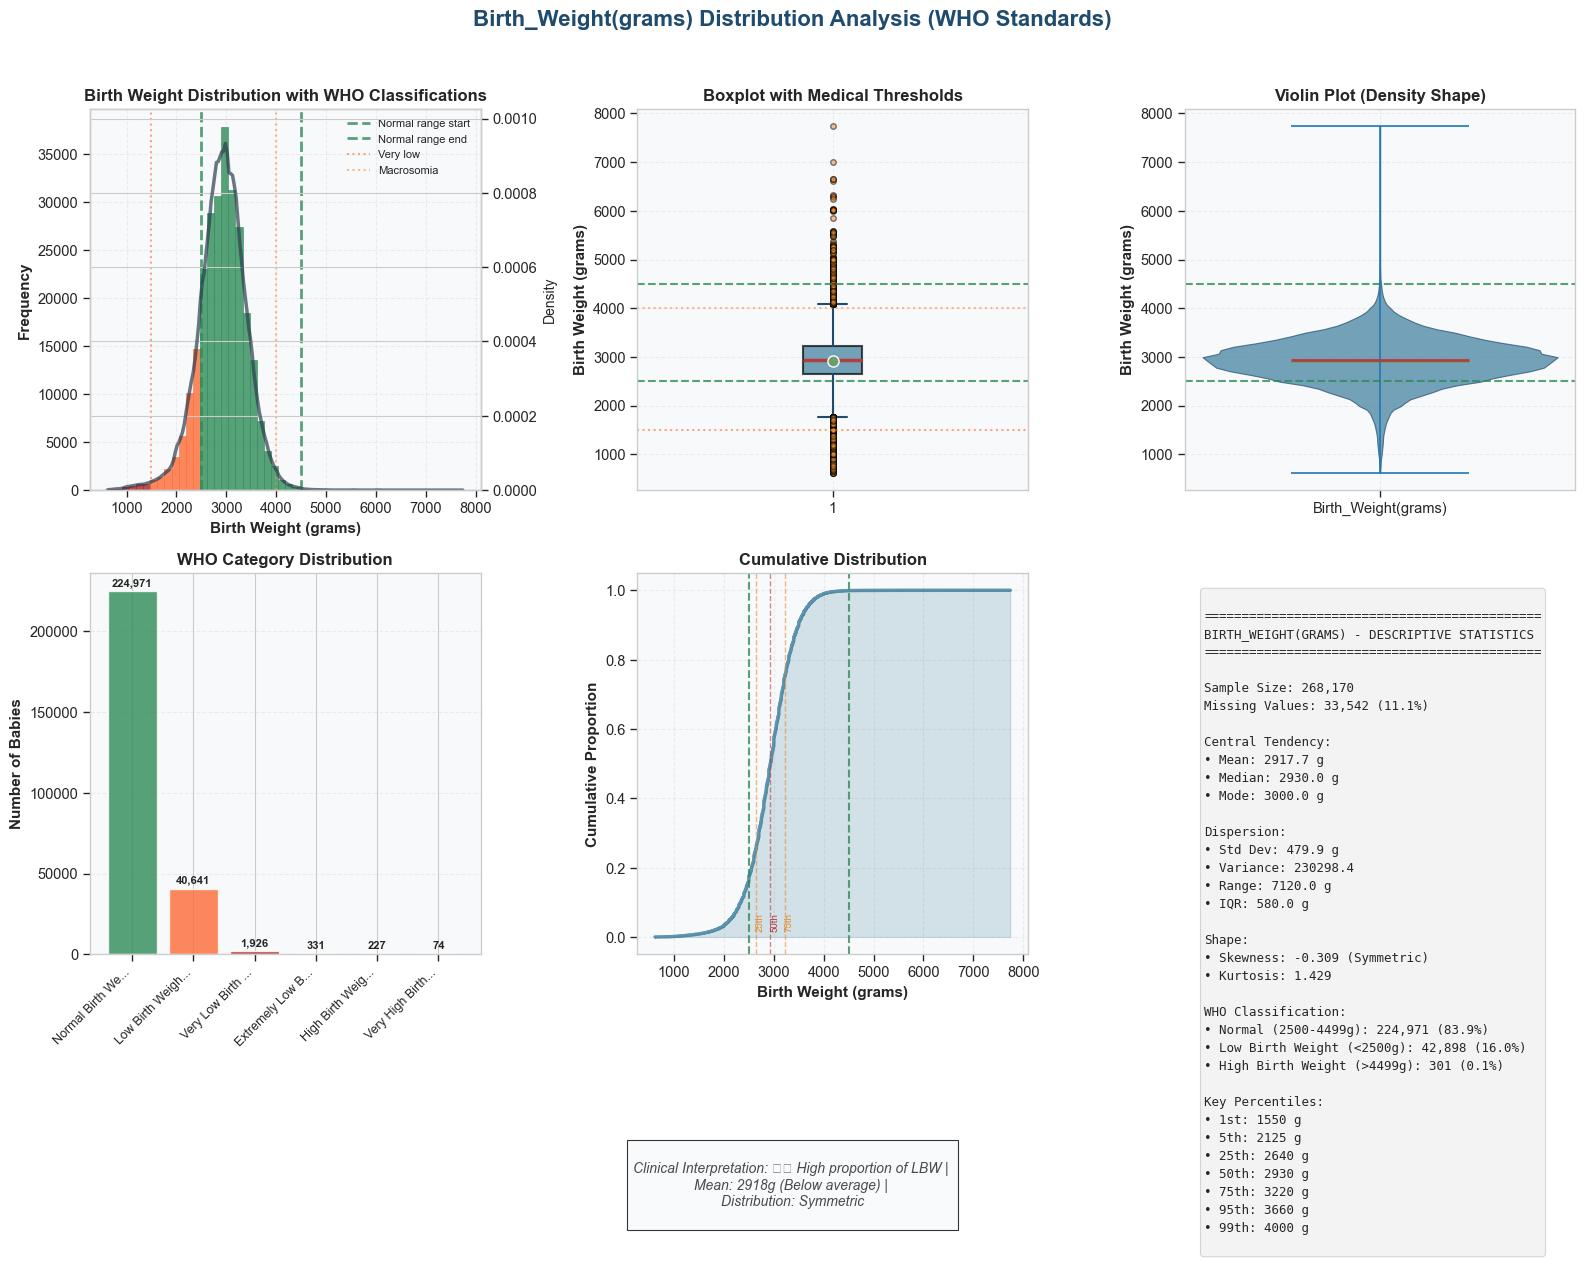


✅ Saved: Birth_Weight(grams)_distribution_analysis.png

────────────────────────────────────────────────────────────────────────────────
📊 EXPORTING TO EXCEL
────────────────────────────────────────────────────────────────────────────────
✅ Excel file saved: Birth_Weight(grams)_descriptive_stats.xlsx

✅ WEIGHT DISTRIBUTION ANALYSIS COMPLETE

📁 FILES CREATED:
   • PNG: Birth_Weight(grams)_distribution_analysis.png
   • Excel: Birth_Weight(grams)_descriptive_stats.xlsx

📊 KEY FINDINGS:
   • Mean birth weight: 2917.7 g
   • Median birth weight: 2930.0 g
   • Normal range (WHO): 2,500 - 4,499 g
   • Low birth weight: 42,898 babies (16.0%)
   • High birth weight: 301 babies (0.1%)


In [3]:


# ============================================
# STEP 1: DEFINE YOUR VARIABLE
# ============================================
TARGET = 'Birth_Weight(grams)'  # <--- CHANGE THIS to analyze different variables
# ============================================

print(f"\n{'='*80}")
print(f"📊 WEIGHT DISTRIBUTION ANALYSIS: '{TARGET}'")
print(f"{'='*80}")

# Check if column exists
if TARGET not in df.columns:
    print(f"❌ ERROR: Column '{TARGET}' not found!")
    print(f"Available columns: {list(df.columns)[:20]}...")
    exit()

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {len(original_data):,}")
print(f"   • Valid records: {len(data):,}")
print(f"   • Missing values: {original_data.isnull().sum():,} ({(original_data.isnull().sum()/len(original_data)*100):.1f}%)")

# ============================================
# STEP 2: DESCRIPTIVE STATISTICS TABLE
# ============================================
print(f"\n{'─'*80}")
print(f"📋 DESCRIPTIVE STATISTICS")
print(f"{'─'*80}")

# Calculate statistics
stats_dict = {
    'Statistic': [
        'Count', 'Mean', 'Median', 'Mode', 'Standard Deviation', 
        'Variance', 'Minimum', 'Maximum', 'Range',
        '25th Percentile (Q1)', '50th Percentile (Median)', '75th Percentile (Q3)',
        'Interquartile Range (IQR)', 'Skewness', 'Kurtosis',
        'Coefficient of Variation (%)'
    ],
    'Value': [
        f"{len(data):,}",
        f"{data.mean():.2f}",
        f"{data.median():.2f}",
        f"{data.mode().iloc[0]:.2f}" if len(data.mode()) > 0 else "N/A",
        f"{data.std():.2f}",
        f"{data.var():.2f}",
        f"{data.min():.2f}",
        f"{data.max():.2f}",
        f"{data.max() - data.min():.2f}",
        f"{data.quantile(0.25):.2f}",
        f"{data.quantile(0.50):.2f}",
        f"{data.quantile(0.75):.2f}",
        f"{data.quantile(0.75) - data.quantile(0.25):.2f}",
        f"{data.skew():.3f}",
        f"{data.kurtosis():.3f}",
        f"{(data.std() / data.mean() * 100):.1f}%"
    ]
}

stats_df = pd.DataFrame(stats_dict)
print(stats_df.to_string(index=False))

# ============================================
# STEP 3: PERCENTILE TABLE
# ============================================
print(f"\n{'─'*80}")
print(f"📊 PERCENTILE TABLE")
print(f"{'─'*80}")

percentiles = [1, 2.5, 5, 10, 25, 50, 75, 90, 95, 97.5, 99]
perc_values = np.percentile(data, percentiles)

perc_df = pd.DataFrame({
    'Percentile': [f"{p}th" for p in percentiles],
    'Value (grams)': [f"{v:.1f}" for v in perc_values],
    'Interpretation': [
        'Extremely low',
        'Very low',
        'Low',
        'Below average',
        'First quartile',
        'Median',
        'Third quartile',
        'Above average',
        'High',
        'Very high',
        'Extremely high'
    ]
})
print(perc_df.to_string(index=False))

# ============================================
# STEP 4: WHO MEDICAL CLASSIFICATION
# ============================================
print(f"\n{'─'*80}")
print(f"🏥 WHO MEDICAL CLASSIFICATION")
print(f"{'─'*80}")

# WHO categories for birth weight
who_categories = {
    'Extremely Low Birth Weight': {'min': 0, 'max': 999, 'color': '#8B0000', 'risk': 'Critical'},
    'Very Low Birth Weight': {'min': 1000, 'max': 1499, 'color': '#B22222', 'risk': 'Very High'},
    'Low Birth Weight': {'min': 1500, 'max': 2499, 'color': '#FF6B35', 'risk': 'High'},
    'Normal Birth Weight': {'min': 2500, 'max': 4499, 'color': '#2E8B57', 'risk': 'Low'},
    'High Birth Weight (Macrosomia)': {'min': 4500, 'max': 4999, 'color': '#FF8C42', 'risk': 'Moderate'},
    'Very High Birth Weight': {'min': 5000, 'max': 9999, 'color': '#B22222', 'risk': 'High'}
}

# Classify each record
classification = []
for value in data:
    for category, details in who_categories.items():
        if details['min'] <= value <= details['max']:
            classification.append({
                'value': value,
                'category': category,
                'risk': details['risk'],
                'color': details['color']
            })
            break

class_df = pd.DataFrame(classification)

# Summary by WHO category
who_summary = class_df.groupby('category').agg({
    'value': ['count', 'mean', 'min', 'max']
}).round(2)
who_summary.columns = ['Count', 'Mean', 'Min', 'Max']
who_summary = who_summary.reset_index()

# Add percentages
total_valid = len(data)
who_summary['Percentage'] = (who_summary['Count'] / total_valid * 100).round(1)
who_summary = who_summary.sort_values('Count', ascending=False)

print(f"\n📋 WHO CLASSIFICATION SUMMARY:")
print(who_summary[['category', 'Count', 'Percentage', 'Mean', 'Min', 'Max']].to_string(index=False))

# Key findings - calculate safely
normal_count = who_summary[who_summary['category'] == 'Normal Birth Weight']['Count'].values[0] if len(who_summary[who_summary['category'] == 'Normal Birth Weight']) > 0 else 0
normal_pct = who_summary[who_summary['category'] == 'Normal Birth Weight']['Percentage'].values[0] if len(who_summary[who_summary['category'] == 'Normal Birth Weight']) > 0 else 0
low_count = who_summary[who_summary['category'].str.contains('Low')]['Count'].sum() if len(who_summary[who_summary['category'].str.contains('Low')]) > 0 else 0
low_pct = who_summary[who_summary['category'].str.contains('Low')]['Percentage'].sum() if len(who_summary[who_summary['category'].str.contains('Low')]) > 0 else 0
high_count = who_summary[who_summary['category'].str.contains('High')]['Count'].sum() if len(who_summary[who_summary['category'].str.contains('High')]) > 0 else 0
high_pct = who_summary[who_summary['category'].str.contains('High')]['Percentage'].sum() if len(who_summary[who_summary['category'].str.contains('High')]) > 0 else 0

print(f"\n📌 KEY FINDINGS:")
print(f"   • Normal birth weight (2,500-4,499g): {normal_count:,} babies ({normal_pct:.1f}%)")
print(f"   • Low birth weight (<2,500g): {low_count:,} babies ({low_pct:.1f}%)")
print(f"   • High birth weight (>4,499g): {high_count:,} babies ({high_pct:.1f}%)")

# ============================================
# STEP 5: WEIGHT DISTRIBUTION PLOT
# ============================================
print(f"\n{'─'*80}")
print(f"🎨 CREATING WEIGHT DISTRIBUTION PLOT")
print(f"{'─'*80}")

# Set style for publication-quality figure
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Create figure with subplots
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')

# 1. Main histogram with KDE (top left)
ax1 = plt.subplot(2, 3, 1)
n, bins, patches = ax1.hist(data, bins=50, edgecolor='white', linewidth=0.5, alpha=0.8)

# Color bars by WHO category
for i in range(len(bins)-1):
    bin_center = (bins[i] + bins[i+1]) / 2
    for category, details in who_categories.items():
        if details['min'] <= bin_center <= details['max']:
            patches[i].set_color(details['color'])
            patches[i].set_alpha(0.8)
            break

# Add KDE curve
kde = stats.gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 200)
ax2_kde = ax1.twinx()
ax2_kde.plot(x_range, kde(x_range), color='#2c3e50', linewidth=2.5, linestyle='-', alpha=0.7)
ax2_kde.set_ylabel('Density', fontsize=10)
ax2_kde.set_ylim(0, max(kde(x_range)) * 1.1)

# Add vertical lines for medical thresholds
ax1.axvline(x=2500, color='#2E8B57', linestyle='--', linewidth=2, alpha=0.8, label='Normal range start')
ax1.axvline(x=4499, color='#2E8B57', linestyle='--', linewidth=2, alpha=0.8, label='Normal range end')
ax1.axvline(x=1500, color='#FF6B35', linestyle=':', linewidth=1.5, alpha=0.6, label='Very low')
ax1.axvline(x=4000, color='#FF8C42', linestyle=':', linewidth=1.5, alpha=0.6, label='Macrosomia')

ax1.set_xlabel('Birth Weight (grams)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Birth Weight Distribution with WHO Classifications', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_facecolor('#f8f9fa')
ax1.grid(True, alpha=0.3, linestyle='--')

# 2. Boxplot (top middle)
ax2 = plt.subplot(2, 3, 2)
bp = ax2.boxplot(data, patch_artist=True, showmeans=True,
                 boxprops=dict(facecolor='#3b7c9c', alpha=0.7, linewidth=1.5),
                 medianprops=dict(color='#b33e3e', linewidth=2.5),
                 meanprops=dict(marker='o', markerfacecolor='#6b9e6b', markeredgecolor='white', markersize=8),
                 whiskerprops=dict(linewidth=1.5, color='#1f4b6e'),
                 capprops=dict(linewidth=1.5, color='#1f4b6e'),
                 flierprops=dict(marker='o', markerfacecolor='#e68a2e', alpha=0.5, markersize=4))

# Add threshold lines
ax2.axhline(y=2500, color='#2E8B57', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axhline(y=4499, color='#2E8B57', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.axhline(y=1500, color='#FF6B35', linestyle=':', linewidth=1.5, alpha=0.6)
ax2.axhline(y=4000, color='#FF8C42', linestyle=':', linewidth=1.5, alpha=0.6)

ax2.set_ylabel('Birth Weight (grams)', fontsize=11, fontweight='bold')
ax2.set_title('Boxplot with Medical Thresholds', fontsize=12, fontweight='bold')
ax2.set_facecolor('#f8f9fa')
ax2.grid(True, alpha=0.3, linestyle='--')

# 3. Violin plot (top right)
ax3 = plt.subplot(2, 3, 3)
violin_parts = ax3.violinplot(data, positions=[1], showmeans=True, showmedians=True)
violin_parts['bodies'][0].set_facecolor('#3b7c9c')
violin_parts['bodies'][0].set_alpha(0.7)
violin_parts['bodies'][0].set_edgecolor('#1f4b6e')
violin_parts['cmeans'].set_color('#6b9e6b')
violin_parts['cmeans'].set_linewidth(2)
violin_parts['cmedians'].set_color('#b33e3e')
violin_parts['cmedians'].set_linewidth(2)

# Add threshold lines
ax3.axhline(y=2500, color='#2E8B57', linestyle='--', linewidth=1.5, alpha=0.8)
ax3.axhline(y=4499, color='#2E8B57', linestyle='--', linewidth=1.5, alpha=0.8)

ax3.set_ylabel('Birth Weight (grams)', fontsize=11, fontweight='bold')
ax3.set_title('Violin Plot (Density Shape)', fontsize=12, fontweight='bold')
ax3.set_xticks([1])
ax3.set_xticklabels([TARGET])
ax3.set_facecolor('#f8f9fa')
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. WHO Category Distribution (bottom left)
ax4 = plt.subplot(2, 3, 4)
categories = who_summary['category'].values
counts = who_summary['Count'].values
colors = [who_categories[cat]['color'] for cat in categories]

bars = ax4.bar(range(len(categories)), counts, color=colors, alpha=0.8, edgecolor='white', linewidth=1)
ax4.set_xticks(range(len(categories)))
ax4.set_xticklabels([c[:15] + '...' if len(c) > 15 else c for c in categories], rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Number of Babies', fontsize=11, fontweight='bold')
ax4.set_title('WHO Category Distribution', fontsize=12, fontweight='bold')
ax4.set_facecolor('#f8f9fa')
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
             f'{count:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 5. Cumulative distribution (bottom middle)
ax5 = plt.subplot(2, 3, 5)
sorted_data = np.sort(data)
y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

ax5.plot(sorted_data, y_vals, linewidth=2.5, color='#3b7c9c', alpha=0.8)
ax5.fill_between(sorted_data, 0, y_vals, alpha=0.2, color='#3b7c9c')

# Add percentile lines
for p, color in zip([25, 50, 75], ['#e68a2e', '#b33e3e', '#e68a2e']):
    val = np.percentile(data, p)
    ax5.axvline(x=val, color=color, linestyle='--', linewidth=1, alpha=0.6)
    ax5.text(val, 0.02, f'{p}th', rotation=90, fontsize=7, color=color)

# Add WHO threshold lines
ax5.axvline(x=2500, color='#2E8B57', linestyle='--', linewidth=1.5, alpha=0.8)
ax5.axvline(x=4499, color='#2E8B57', linestyle='--', linewidth=1.5, alpha=0.8)

ax5.set_xlabel('Birth Weight (grams)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Cumulative Proportion', fontsize=11, fontweight='bold')
ax5.set_title('Cumulative Distribution', fontsize=12, fontweight='bold')
ax5.set_facecolor('#f8f9fa')
ax5.grid(True, alpha=0.3, linestyle='--')

# 6. Descriptive Statistics Text (bottom right)
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Create formatted statistics text - USING TARGET (not BIRTH_WEIGHT)
stats_text = f"""
{'='*45}
{TARGET.upper()} - DESCRIPTIVE STATISTICS
{'='*45}

Sample Size: {len(data):,}
Missing Values: {original_data.isnull().sum():,} ({(original_data.isnull().sum()/len(original_data)*100):.1f}%)

Central Tendency:
• Mean: {data.mean():.1f} g
• Median: {data.median():.1f} g
• Mode: {data.mode().iloc[0]:.1f} g

Dispersion:
• Std Dev: {data.std():.1f} g
• Variance: {data.var():.1f}
• Range: {data.max() - data.min():.1f} g
• IQR: {data.quantile(0.75) - data.quantile(0.25):.1f} g

Shape:
• Skewness: {data.skew():.3f} ({'Symmetric' if abs(data.skew()) < 0.5 else 'Moderately skewed' if abs(data.skew()) < 1 else 'Highly skewed'})
• Kurtosis: {data.kurtosis():.3f}

WHO Classification:
• Normal (2500-4499g): {normal_count:,} ({normal_pct:.1f}%)
• Low Birth Weight (<2500g): {low_count:,} ({low_pct:.1f}%)
• High Birth Weight (>4499g): {high_count:,} ({high_pct:.1f}%)

Key Percentiles:
• 1st: {np.percentile(data, 1):.0f} g
• 5th: {np.percentile(data, 5):.0f} g
• 25th: {np.percentile(data, 25):.0f} g
• 50th: {np.percentile(data, 50):.0f} g
• 75th: {np.percentile(data, 75):.0f} g
• 95th: {np.percentile(data, 95):.0f} g
• 99th: {np.percentile(data, 99):.0f} g
"""

ax6.text(0.05, 0.95, stats_text, fontsize=9, verticalalignment='top',
         family='monospace', linespacing=1.5,
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='#cccccc', alpha=0.8))

# Main title
plt.suptitle(f'{TARGET} Distribution Analysis (WHO Standards)', 
             fontsize=16, fontweight='bold', y=1.02, color='#1f4b6e')

# Add footer with interpretation
lbw_alert = "⚠️ High proportion of LBW" if low_pct > 10 else "✅ Normal LBW rate"
mean_comparison = "Below" if data.mean() < 3000 else "Above"
skew_desc = "Symmetric" if abs(data.skew()) < 0.5 else "Skewed"

interpretation = f"""
Clinical Interpretation: {lbw_alert} | 
Mean: {data.mean():.0f}g ({mean_comparison} average) | 
Distribution: {skew_desc}
"""
plt.figtext(0.5, 0.01, interpretation, ha='center', fontsize=10, 
            style='italic', color='#4a4a4a', bbox=dict(facecolor='#f8f9fa', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{TARGET}_distribution_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Saved: {TARGET}_distribution_analysis.png")

# ============================================
# STEP 6: EXPORT TO EXCEL
# ============================================
print(f"\n{'─'*80}")
print(f"📊 EXPORTING TO EXCEL")
print(f"{'─'*80}")

excel_filename = f'{TARGET}_descriptive_stats.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Descriptive statistics
    stats_df.to_excel(writer, sheet_name='Descriptive_Stats', index=False)
    
    # Percentile table
    perc_df.to_excel(writer, sheet_name='Percentiles', index=False)
    
    # WHO classification
    who_summary.to_excel(writer, sheet_name='WHO_Classification', index=False)
    
    # All records with classification
    records_df = pd.DataFrame({
        TARGET: data.values,
        'WHO_Category': class_df['category'].values,
        'Risk_Level': class_df['risk'].values
    })
    records_df.to_excel(writer, sheet_name='All_Records', index=False)

print(f"✅ Excel file saved: {excel_filename}")

# ============================================
# FINAL SUMMARY
# ============================================
print(f"\n{'='*80}")
print(f"✅ WEIGHT DISTRIBUTION ANALYSIS COMPLETE")
print(f"{'='*80}")
print(f"\n📁 FILES CREATED:")
print(f"   • PNG: {TARGET}_distribution_analysis.png")
print(f"   • Excel: {excel_filename}")
print(f"\n📊 KEY FINDINGS:")
print(f"   • Mean birth weight: {data.mean():.1f} g")
print(f"   • Median birth weight: {data.median():.1f} g")
print(f"   • Normal range (WHO): 2,500 - 4,499 g")
print(f"   • Low birth weight: {low_count:,} babies ({low_pct:.1f}%)")
print(f"   • High birth weight: {high_count:,} babies ({high_pct:.1f}%)")
print(f"{'='*80}")

✅ Loaded 301,712 records
📋 Columns: ['Registered_Year', 'Registered_Month2.0', 'Registered_Month', 'Registered_District', 'Birh_Year', 'Birth_Month.0', 'Birth_Month', 'Gender', 'Hospital or Not', 'Multiple_Birth_Status', 'Birth_Weight(grams)', 'Birth_Order', 'Birth_Order - Copy', 'Age of Mother', 'Marital_Status', 'District_of_Mother', 'Race_of_Mother', 'Race_of_Father']

📍 Setting up Sri Lankan districts...
   • 25 districts defined

🔍 Identifying Sri Lankan Moor population...

📋 Value counts in Race_of_Mother:
Race_of_Mother
Sinhalese          208395
Srilankan Moor      41678
Srilankan Tamil     35928
Indian Tamil        14341
NaN                   520
Malay                 444
Burgher               406
Name: count, dtype: int64

📋 Value counts in Race_of_Father:
Race_of_Father
Sinhalese          208352
Srilankan Moor      41554
Srilankan Tamil     35188
Indian Tamil        14480
NaN                  1231
Malay                 474
Burgher               433
Name: count, dtype: int64



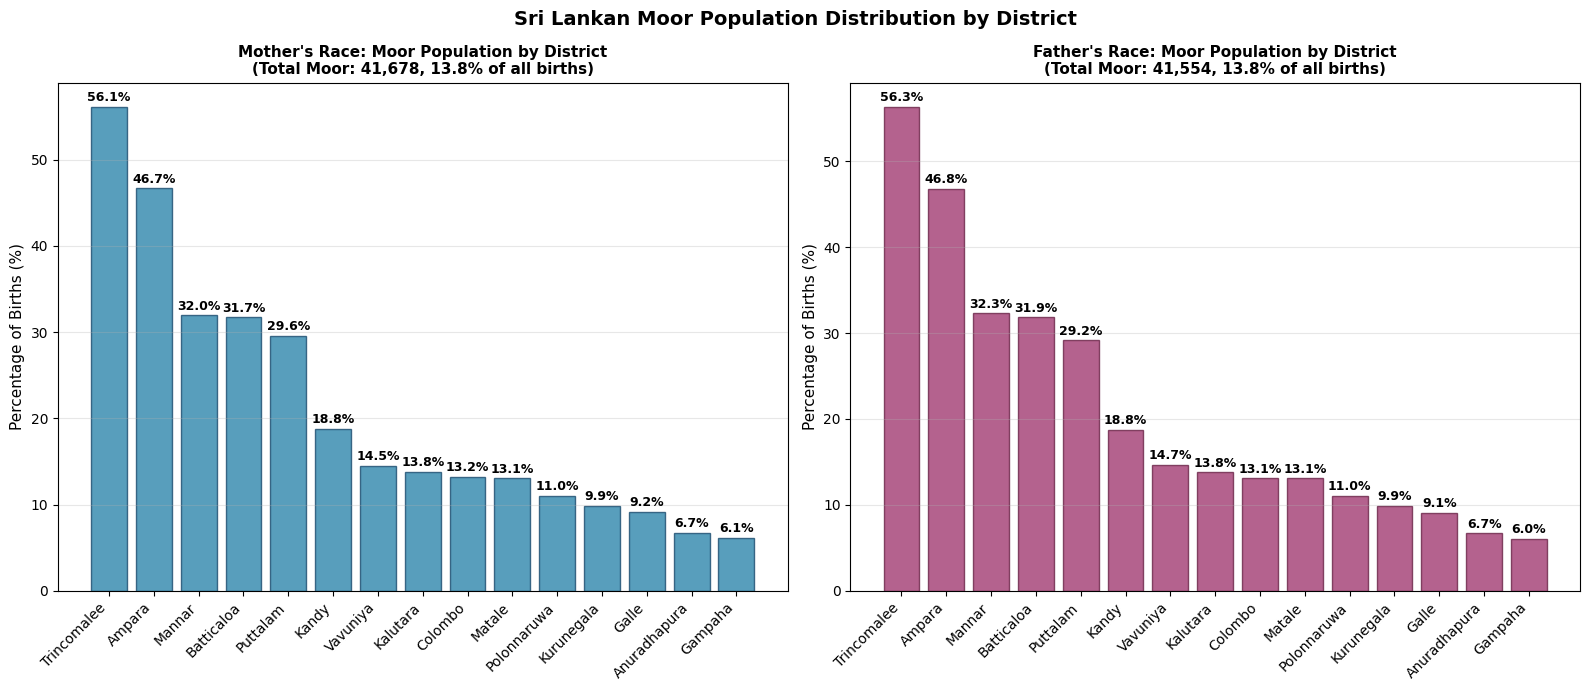


✅ Saved: moor_population_distribution.png

📊 Exporting to Excel...
✅ Saved: moor_population_analysis.xlsx

✅ ANALYSIS COMPLETE

📍 Mother's Race - Top 5 Districts:
   1. Trincomalee: 56.1% (4,738 of 8,443 births)
   2. Ampara: 46.7% (6,784 of 14,527 births)
   3. Mannar: 32.0% (611 of 1,911 births)
   4. Batticaloa: 31.7% (3,034 of 9,566 births)
   5. Puttalam: 29.6% (3,652 of 12,344 births)

📍 Father's Race - Top 5 Districts:
   1. Trincomalee: 56.3% (4,753 of 8,443 births)
   2. Ampara: 46.8% (6,793 of 14,527 births)
   3. Mannar: 32.3% (617 of 1,911 births)
   4. Batticaloa: 31.9% (3,047 of 9,566 births)
   5. Puttalam: 29.2% (3,600 of 12,344 births)

📁 FILES CREATED:
   • Chart: moor_population_distribution.png
   • Excel: moor_population_analysis.xlsx


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path


# OPTION 2: If file is in a specific path (uncomment and modify as needed)
# DATA_PATH = Path("../../data/raw")
# df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")

print(f"✅ Loaded {len(df):,} records")
print(f"📋 Columns: {df.columns.tolist()}")

# ============================================
# DEFINE SRI LANKAN DISTRICTS MANUALLY
# ============================================
print("\n📍 Setting up Sri Lankan districts...")

# Complete list of Sri Lankan districts with correct spellings
sri_lanka_districts = [
    'Colombo', 'Gampaha', 'Kalutara', 'Kandy', 'Matale', 'Nuwara Eliya',
    'Galle', 'Matara', 'Hambantota', 'Jaffna', 'Kilinochchi', 'Mannar',
    'Vavuniya', 'Mullaitivu', 'Batticaloa', 'Ampara', 'Trincomalee',
    'Kurunegala', 'Puttalam', 'Anuradhapura', 'Polonnaruwa', 'Badulla',
    'Moneragala', 'Ratnapura', 'Kegalle'
]

# Dictionary to handle alternative spellings
district_variations = {
    'Colombo': ['Colombo', 'colombo'],
    'Gampaha': ['Gampaha', 'gampaha'],
    'Kalutara': ['Kalutara', 'kalutara'],
    'Kandy': ['Kandy', 'kandy', 'Mahanuwara'],
    'Matale': ['Matale', 'matale'],
    'Nuwara Eliya': ['Nuwara Eliya', 'nuwara eliya', 'Nuwaraeliya'],
    'Galle': ['Galle', 'galle'],
    'Matara': ['Matara', 'matara'],
    'Hambantota': ['Hambantota', 'hambantota'],
    'Jaffna': ['Jaffna', 'jaffna', 'Yapanaya'],
    'Kilinochchi': ['Kilinochchi', 'kilinochchi'],
    'Mannar': ['Mannar', 'mannar'],
    'Vavuniya': ['Vavuniya', 'vavuniya'],
    'Mullaitivu': ['Mullaitivu', 'mullaitivu'],
    'Batticaloa': ['Batticaloa', 'batticaloa', 'Madakalapuwa'],
    'Ampara': ['Ampara', 'ampara'],
    'Trincomalee': ['Trincomalee', 'trincomalee', 'Thirukonamale'],
    'Kurunegala': ['Kurunegala', 'kurunegala', 'Kurunagala'],  # Note your data has 'Kurunagala'
    'Puttalam': ['Puttalam', 'puttalam'],
    'Anuradhapura': ['Anuradhapura', 'anuradhapura', 'Anuradapura'],  # Your data has 'Anuradapura'
    'Polonnaruwa': ['Polonnaruwa', 'polonnaruwa'],
    'Badulla': ['Badulla', 'badulla'],
    'Moneragala': ['Moneragala', 'moneragala'],
    'Ratnapura': ['Ratnapura', 'ratnapura'],
    'Kegalle': ['Kegalle', 'kegalle']
}

print(f"   • {len(sri_lanka_districts)} districts defined")

# ============================================
# IDENTIFY MOOR POPULATION
# ============================================
print("\n🔍 Identifying Sri Lankan Moor population...")

# Check what values exist in your data
print("\n📋 Value counts in Race_of_Mother:")
print(df['Race_of_Mother'].value_counts(dropna=False).head(10))

print("\n📋 Value counts in Race_of_Father:")
print(df['Race_of_Father'].value_counts(dropna=False).head(10))

def is_moor(race):
    """Check if race is Moor"""
    if pd.isna(race):
        return False
    race = str(race).strip()
    # Based on your data, these are the Moor values
    return race in ['Srilankan Moor', 'Sri Lankan Moor', 'Moor']

# Create Moor indicator columns
df['Mother_Is_Moor'] = df['Race_of_Mother'].apply(is_moor)
df['Father_Is_Moor'] = df['Race_of_Father'].apply(is_moor)

# Count Moor population
total_moor_mother = df['Mother_Is_Moor'].sum()
total_moor_father = df['Father_Is_Moor'].sum()
total_records = len(df)

print(f"\n📊 MOOR POPULATION COUNTS:")
print(f"   • Total records: {total_records:,}")
print(f"   • Moor mothers: {total_moor_mother:,} ({total_moor_mother/total_records*100:.2f}%)")
print(f"   • Moor fathers: {total_moor_father:,} ({total_moor_father/total_records*100:.2f}%)")

# ============================================
# CALCULATE MOOR PERCENTAGES BY DISTRICT
# ============================================
print("\n🧮 Calculating Moor percentages by district...")

def find_district(district_name, variations_dict):
    """Find the standardized district name"""
    if pd.isna(district_name):
        return None
    district_name = str(district_name).strip()
    for std_name, variants in variations_dict.items():
        if any(variant.lower() == district_name.lower() for variant in variants):
            return std_name
        if any(variant.lower() in district_name.lower() for variant in variants):
            return std_name
    return None

# Calculate for each district
mother_results = []
father_results = []

for district in sri_lanka_districts:
    # Find all records in this district using variations
    district_mask = df['Registered_District'].apply(
        lambda x: find_district(x, district_variations) == district if pd.notna(x) else False
    )
    
    district_data = df[district_mask]
    total_births = len(district_data)
    
    if total_births > 0:
        moor_mothers = district_data['Mother_Is_Moor'].sum()
        moor_fathers = district_data['Father_Is_Moor'].sum()
        
        pct_mothers = (moor_mothers / total_births * 100) if total_births > 0 else 0
        pct_fathers = (moor_fathers / total_births * 100) if total_births > 0 else 0
        
        mother_results.append({
            'district': district,
            'total_births': total_births,
            'moor_count': moor_mothers,
            'percentage': round(pct_mothers, 2)
        })
        
        father_results.append({
            'district': district,
            'total_births': total_births,
            'moor_count': moor_fathers,
            'percentage': round(pct_fathers, 2)
        })

# Convert to DataFrames
mother_df = pd.DataFrame(mother_results)
father_df = pd.DataFrame(father_results)

# Filter districts with data and sort
mother_df = mother_df[mother_df['total_births'] > 0].sort_values('percentage', ascending=False).reset_index(drop=True)
father_df = father_df[father_df['total_births'] > 0].sort_values('percentage', ascending=False).reset_index(drop=True)

print(f"\n   • Districts with Moor mothers: {len(mother_df)}")
print(f"   • Districts with Moor fathers: {len(father_df)}")

# ============================================
# DISPLAY RESULTS
# ============================================
print(f"\n{'='*90}")
print(f"📊 MOOR POPULATION PERCENTAGES BY DISTRICT")
print(f"{'='*90}")

if len(mother_df) > 0:
    print(f"\n🏥 BASED ON MOTHER'S RACE (Total Moor: {total_moor_mother:,})")
    print("-" * 80)
    print(f"{'Rank':<4} {'District':<20} {'Total Births':>12} {'Moor Births':>12} {'Percentage':>12}")
    print("-" * 80)
    for idx, row in mother_df.iterrows():
        if row['moor_count'] > 0:
            print(f"{idx+1:<4} {row['district']:<20} {row['total_births']:>12,} {row['moor_count']:>12,} {row['percentage']:>11.1f}%")

if len(father_df) > 0:
    print(f"\n🏥 BASED ON FATHER'S RACE (Total Moor: {total_moor_father:,})")
    print("-" * 80)
    print(f"{'Rank':<4} {'District':<20} {'Total Births':>12} {'Moor Births':>12} {'Percentage':>12}")
    print("-" * 80)
    for idx, row in father_df.iterrows():
        if row['moor_count'] > 0:
            print(f"{idx+1:<4} {row['district']:<20} {row['total_births']:>12,} {row['moor_count']:>12,} {row['percentage']:>11.1f}%")

# ============================================
# CREATE VISUALIZATION
# ============================================
print(f"\n🎨 Creating visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# Mother's Race - Top districts
if len(mother_df) > 0:
    top_mother = mother_df.head(min(15, len(mother_df)))
    x_pos = range(len(top_mother))
    bars1 = ax1.bar(x_pos, top_mother['percentage'].values, 
                    color='#2E86AB', alpha=0.8, edgecolor='#1A4B6E', linewidth=1)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(top_mother['district'].values, rotation=45, ha='right', fontsize=10)
    ax1.set_ylabel('Percentage of Births (%)', fontsize=11)
    ax1.set_title(f'Mother\'s Race: Moor Population by District\n(Total Moor: {total_moor_mother:,}, {total_moor_mother/total_records*100:.1f}% of all births)', 
                  fontweight='bold', fontsize=11)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars1, top_mother['percentage'].values):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax1.transAxes)

# Father's Race - Top districts
if len(father_df) > 0:
    top_father = father_df.head(min(15, len(father_df)))
    x_pos = range(len(top_father))
    bars2 = ax2.bar(x_pos, top_father['percentage'].values, 
                    color='#A23B72', alpha=0.8, edgecolor='#6A2347', linewidth=1)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(top_father['district'].values, rotation=45, ha='right', fontsize=10)
    ax2.set_ylabel('Percentage of Births (%)', fontsize=11)
    ax2.set_title(f'Father\'s Race: Moor Population by District\n(Total Moor: {total_moor_father:,}, {total_moor_father/total_records*100:.1f}% of all births)', 
                  fontweight='bold', fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars2, top_father['percentage'].values):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax2.transAxes)

plt.suptitle('Sri Lankan Moor Population Distribution by District', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('moor_population_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Saved: moor_population_distribution.png")

# ============================================
# EXPORT TO EXCEL
# ============================================
print(f"\n📊 Exporting to Excel...")

excel_filename = 'moor_population_analysis.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    if len(mother_df) > 0:
        mother_df.to_excel(writer, sheet_name='Mother_Race', index=False)
    if len(father_df) > 0:
        father_df.to_excel(writer, sheet_name='Father_Race', index=False)
    
    # Summary sheet
    summary_data = {
        'Metric': [
            'Total Records',
            'Total Moor (Mother)',
            'Total Moor (Father)',
            'Moor % of Total (Mother)',
            'Moor % of Total (Father)',
            'Districts with Moor (Mother)',
            'Districts with Moor (Father)'
        ],
        'Value': [
            f"{total_records:,}",
            f"{total_moor_mother:,}",
            f"{total_moor_father:,}",
            f"{total_moor_mother/total_records*100:.2f}%",
            f"{total_moor_father/total_records*100:.2f}%",
            len(mother_df),
            len(father_df)
        ]
    }
    
    # Add top districts if available
    if len(mother_df) > 0:
        summary_data['Metric'].append('Highest District (Mother)')
        summary_data['Value'].append(f"{mother_df.iloc[0]['district']} ({mother_df.iloc[0]['percentage']:.1f}%)")
    
    if len(father_df) > 0:
        summary_data['Metric'].append('Highest District (Father)')
        summary_data['Value'].append(f"{father_df.iloc[0]['district']} ({father_df.iloc[0]['percentage']:.1f}%)")
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

print(f"✅ Saved: {excel_filename}")

# ============================================
# FINAL SUMMARY
# ============================================
print(f"\n{'='*90}")
print(f"✅ ANALYSIS COMPLETE")
print(f"{'='*90}")

if len(mother_df) > 0:
    print(f"\n📍 Mother's Race - Top 5 Districts:")
    for i in range(min(5, len(mother_df))):
        row = mother_df.iloc[i]
        print(f"   {i+1}. {row['district']}: {row['percentage']:.1f}% ({row['moor_count']:,} of {row['total_births']:,} births)")

if len(father_df) > 0:
    print(f"\n📍 Father's Race - Top 5 Districts:")
    for i in range(min(5, len(father_df))):
        row = father_df.iloc[i]
        print(f"   {i+1}. {row['district']}: {row['percentage']:.1f}% ({row['moor_count']:,} of {row['total_births']:,} births)")

print(f"\n📁 FILES CREATED:")
print(f"   • Chart: moor_population_distribution.png")
print(f"   • Excel: {excel_filename}")
print(f"{'='*90}")


🗺️ Loading Sri Lankan district boundaries...
⚠️ Natural Earth data not available: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

📌 Using manual district coordinates instead...
✅ Created 25 manual district polygons

🔍 Identifying Sri Lankan Moor population...

📊 TOTAL MOOR POPULATION IN SRI LANKA:
   • Moor mothers: 41,678 (13.81% of all births)
   • Moor fathers: 41,554 (13.77% of all births)

🧮 Calculating Moor population by district...

   • Districts with Moor mothers: 25
   • Districts with Moor fathers: 25

🎨 Creating publication-quality maps...


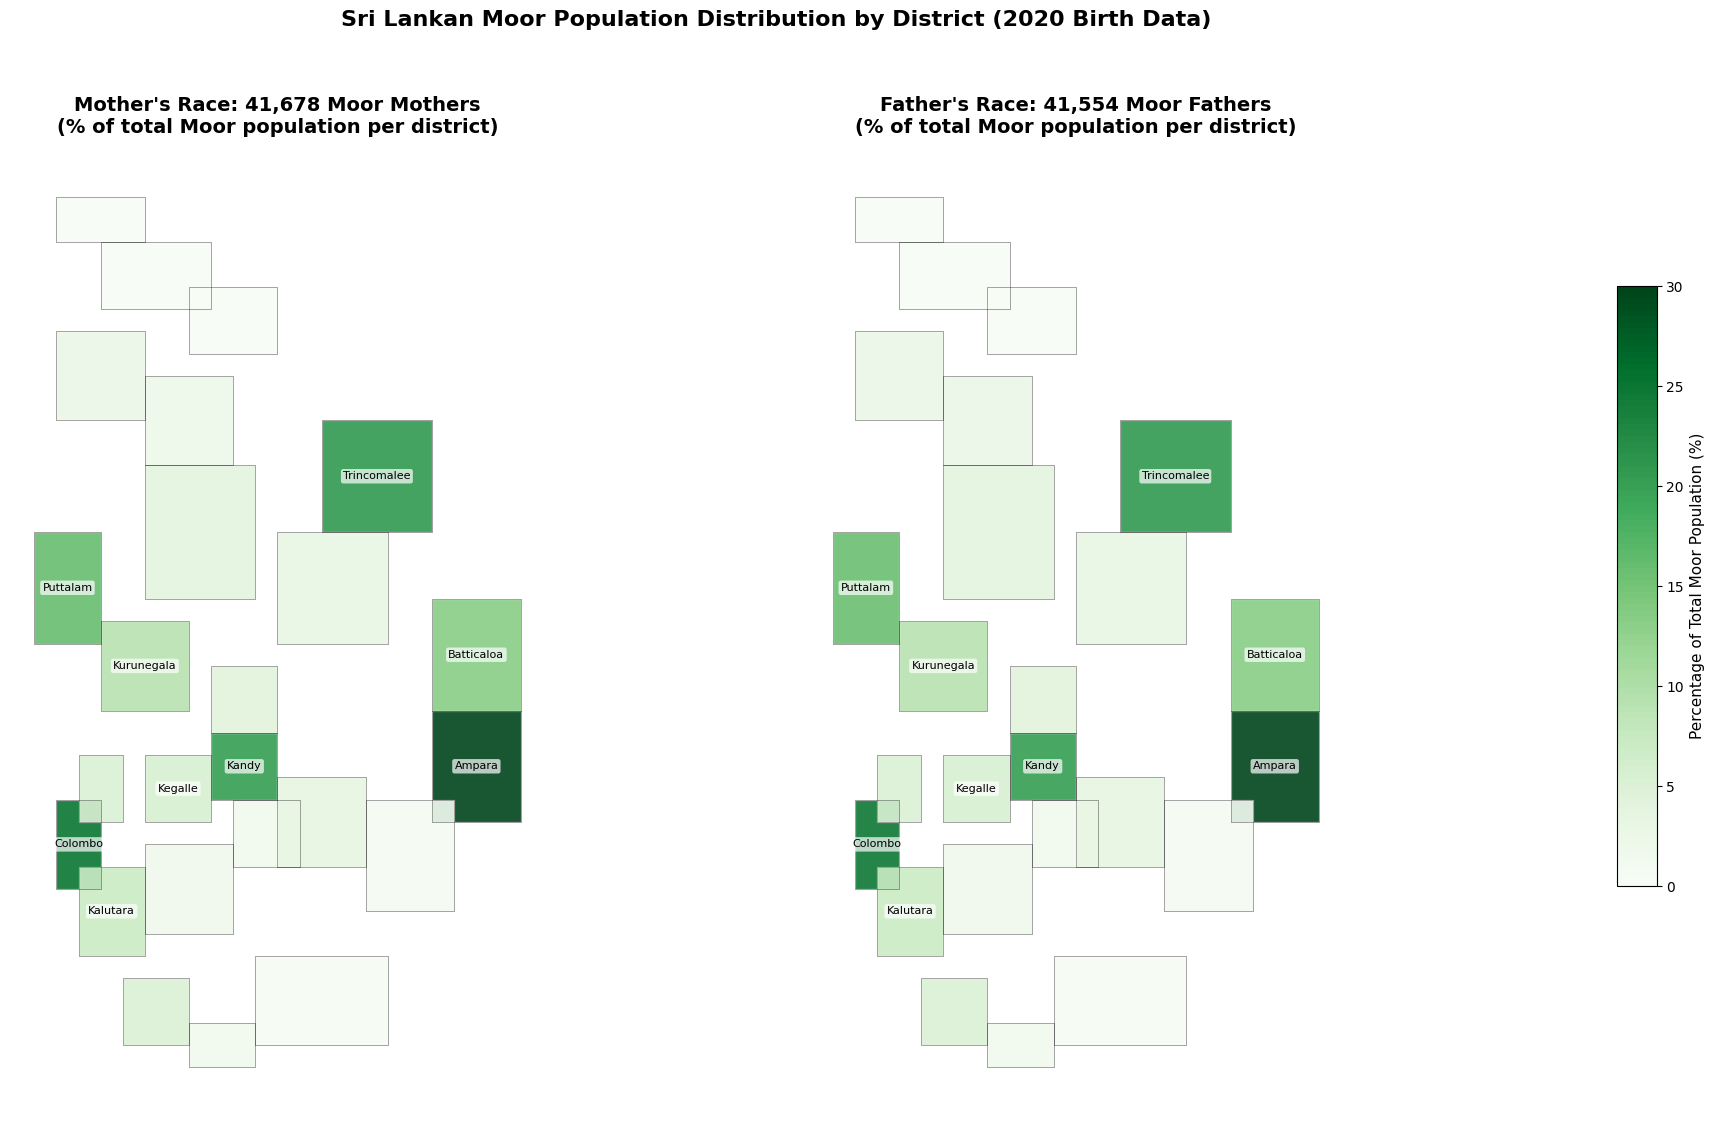


✅ Saved: sri_lanka_moor_maps.png

📊 MOOR POPULATION DISTRIBUTION BY DISTRICT

District             Moor Mothers % of Total Moor Fathers % of Total
----------------------------------------------------------------------
Ampara                      6,784      16.3%        6,793      16.4%
Colombo                     5,644      13.5%        5,600      13.5%
Trincomalee                 4,738      11.4%        4,753      11.4%
Kandy                       4,586      11.0%        4,569      11.0%
Puttalam                    3,652       8.8%        3,600       8.7%
Batticaloa                  3,034       7.3%        3,047       7.3%
Kurunegala                  2,054       4.9%        2,059       5.0%
Kalutara                    1,612       3.9%        1,609       3.9%
Kegalle                     1,267       3.0%        1,258       3.0%
Galle                       1,187       2.9%        1,165       2.8%
Gampaha                     1,183       2.8%        1,165       2.8%
Matale                

In [5]:


# ============================================
# GET SRI LANKAN DISTRICT BOUNDARIES (Alternative Method)
# ============================================
print("\n🗺️ Loading Sri Lankan district boundaries...")

# Method 1: Try to get from Natural Earth (world boundaries)
try:
    # Get world boundaries at admin level 1 (provinces/states)
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    
    # Filter for Sri Lanka
    sri_lanka = world[world['name'] == 'Sri Lanka']
    
    if len(sri_lanka) > 0:
        print("✅ Found Sri Lanka boundaries from Natural Earth")
        # This gives country-level only, not districts
        districts_gdf = sri_lanka
    else:
        raise ValueError("Sri Lanka not found in Natural Earth")
        
except Exception as e:
    print(f"⚠️ Natural Earth data not available: {e}")
    print("\n📌 Using manual district coordinates instead...")
    
    # Create manual district polygons (simplified)
    from shapely.geometry import Point, Polygon
    
    # Sri Lankan districts with approximate boundaries
    # These are simplified - for research, you'd want actual shapefiles
    district_coords = {
        'Colombo': [(79.8, 6.7), (80.0, 6.7), (80.0, 7.1), (79.8, 7.1)],
        'Gampaha': [(79.9, 7.0), (80.1, 7.0), (80.1, 7.3), (79.9, 7.3)],
        'Kalutara': [(79.9, 6.4), (80.2, 6.4), (80.2, 6.8), (79.9, 6.8)],
        'Kandy': [(80.5, 7.1), (80.8, 7.1), (80.8, 7.4), (80.5, 7.4)],
        'Matale': [(80.5, 7.4), (80.8, 7.4), (80.8, 7.7), (80.5, 7.7)],
        'Nuwara Eliya': [(80.6, 6.8), (80.9, 6.8), (80.9, 7.1), (80.6, 7.1)],
        'Galle': [(80.1, 6.0), (80.4, 6.0), (80.4, 6.3), (80.1, 6.3)],
        'Matara': [(80.4, 5.9), (80.7, 5.9), (80.7, 6.1), (80.4, 6.1)],
        'Hambantota': [(80.7, 6.0), (81.3, 6.0), (81.3, 6.4), (80.7, 6.4)],
        'Jaffna': [(79.8, 9.6), (80.2, 9.6), (80.2, 9.8), (79.8, 9.8)],
        'Kilinochchi': [(80.0, 9.3), (80.5, 9.3), (80.5, 9.6), (80.0, 9.6)],
        'Mannar': [(79.8, 8.8), (80.2, 8.8), (80.2, 9.2), (79.8, 9.2)],
        'Vavuniya': [(80.2, 8.6), (80.6, 8.6), (80.6, 9.0), (80.2, 9.0)],
        'Mullaitivu': [(80.4, 9.1), (80.8, 9.1), (80.8, 9.4), (80.4, 9.4)],
        'Batticaloa': [(81.5, 7.5), (81.9, 7.5), (81.9, 8.0), (81.5, 8.0)],
        'Ampara': [(81.5, 7.0), (81.9, 7.0), (81.9, 7.5), (81.5, 7.5)],
        'Trincomalee': [(81.0, 8.3), (81.5, 8.3), (81.5, 8.8), (81.0, 8.8)],
        'Kurunegala': [(80.0, 7.5), (80.4, 7.5), (80.4, 7.9), (80.0, 7.9)],
        'Puttalam': [(79.7, 7.8), (80.0, 7.8), (80.0, 8.3), (79.7, 8.3)],
        'Anuradhapura': [(80.2, 8.0), (80.7, 8.0), (80.7, 8.6), (80.2, 8.6)],
        'Polonnaruwa': [(80.8, 7.8), (81.3, 7.8), (81.3, 8.3), (80.8, 8.3)],
        'Badulla': [(80.8, 6.8), (81.2, 6.8), (81.2, 7.2), (80.8, 7.2)],
        'Moneragala': [(81.2, 6.6), (81.6, 6.6), (81.6, 7.1), (81.2, 7.1)],
        'Ratnapura': [(80.2, 6.5), (80.6, 6.5), (80.6, 6.9), (80.2, 6.9)],
        'Kegalle': [(80.2, 7.0), (80.5, 7.0), (80.5, 7.3), (80.2, 7.3)]
    }
    
    # Create GeoDataFrame
    geometries = []
    districts = []
    
    for district, coords in district_coords.items():
        polygon = Polygon(coords)
        geometries.append(polygon)
        districts.append(district)
    
    districts_gdf = gpd.GeoDataFrame({
        'name': districts,
        'geometry': geometries
    }, crs='EPSG:4326')
    
    print(f"✅ Created {len(districts_gdf)} manual district polygons")

# ============================================
# IDENTIFY MOOR POPULATION
# ============================================
print("\n🔍 Identifying Sri Lankan Moor population...")

def is_moor(race):
    """Check if race is Moor"""
    if pd.isna(race):
        return False
    race = str(race).strip()
    return race in ['Srilankan Moor', 'Sri Lankan Moor', 'Moor']

# Create Moor indicator columns
df['Mother_Is_Moor'] = df['Race_of_Mother'].apply(is_moor)
df['Father_Is_Moor'] = df['Race_of_Father'].apply(is_moor)

# TOTAL Moor population in Sri Lanka
total_moor_mother = df['Mother_Is_Moor'].sum()
total_moor_father = df['Father_Is_Moor'].sum()
total_records = len(df)

print(f"\n📊 TOTAL MOOR POPULATION IN SRI LANKA:")
print(f"   • Moor mothers: {total_moor_mother:,} ({total_moor_mother/total_records*100:.2f}% of all births)")
print(f"   • Moor fathers: {total_moor_father:,} ({total_moor_father/total_records*100:.2f}% of all births)")

# ============================================
# CALCULATE MOOR COUNTS BY DISTRICT
# ============================================
print("\n🧮 Calculating Moor population by district...")

# District name mapping (handle variations)
district_variations = {
    'Colombo': ['Colombo', 'colombo'],
    'Gampaha': ['Gampaha', 'gampaha'],
    'Kalutara': ['Kalutara', 'kalutara'],
    'Kandy': ['Kandy', 'kandy'],
    'Matale': ['Matale', 'matale'],
    'Nuwara Eliya': ['Nuwara Eliya', 'Nuwaraeliya', 'nuwara eliya'],
    'Galle': ['Galle', 'galle'],
    'Matara': ['Matara', 'matara'],
    'Hambantota': ['Hambantota', 'hambantota'],
    'Jaffna': ['Jaffna', 'jaffna'],
    'Kilinochchi': ['Kilinochchi', 'kilinochchi'],
    'Mannar': ['Mannar', 'mannar'],
    'Vavuniya': ['Vavuniya', 'vavuniya'],
    'Mullaitivu': ['Mullaitivu', 'mullaitivu'],
    'Batticaloa': ['Batticaloa', 'batticaloa'],
    'Ampara': ['Ampara', 'ampara'],
    'Trincomalee': ['Trincomalee', 'trincomalee'],
    'Kurunegala': ['Kurunegala', 'kurunegala', 'Kurunagala'],
    'Puttalam': ['Puttalam', 'puttalam'],
    'Anuradhapura': ['Anuradhapura', 'anuradhapura', 'Anuradapura'],
    'Polonnaruwa': ['Polonnaruwa', 'polonnaruwa'],
    'Badulla': ['Badulla', 'badulla'],
    'Moneragala': ['Moneragala', 'moneragala'],
    'Ratnapura': ['Ratnapura', 'ratnapura'],
    'Kegalle': ['Kegalle', 'kegalle']
}

# Create lookup dictionary
lookup = {}
for std_name, variants in district_variations.items():
    for v in variants:
        lookup[v.lower()] = std_name

def match_district(name):
    """Match district name from data to standardized name"""
    if pd.isna(name):
        return None
    name_lower = str(name).strip().lower()
    return lookup.get(name_lower, None)

# Calculate stats for each district
district_stats = []

for idx, row in districts_gdf.iterrows():
    district_name = row['name']
    
    # Find matching records
    matched_names = [district_name]
    for var in district_variations.get(district_name, []):
        matched_names.append(var)
    
    # Create mask for this district
    mask = df['Registered_District'].apply(
        lambda x: match_district(x) == district_name if pd.notna(x) else False
    )
    
    district_data = df[mask]
    total_births = len(district_data)
    
    if total_births > 0:
        moor_mothers = district_data['Mother_Is_Moor'].sum()
        moor_fathers = district_data['Father_Is_Moor'].sum()
        
        # Percentage of TOTAL Moor population
        pct_of_total_mothers = (moor_mothers / total_moor_mother * 100) if total_moor_mother > 0 else 0
        pct_of_total_fathers = (moor_fathers / total_moor_father * 100) if total_moor_father > 0 else 0
        
        district_stats.append({
            'district': district_name,
            'total_births': total_births,
            'moor_mothers': moor_mothers,
            'moor_fathers': moor_fathers,
            'pct_mothers_of_total': round(pct_of_total_mothers, 2),
            'pct_fathers_of_total': round(pct_of_total_fathers, 2)
        })
    else:
        district_stats.append({
            'district': district_name,
            'total_births': 0,
            'moor_mothers': 0,
            'moor_fathers': 0,
            'pct_mothers_of_total': 0,
            'pct_fathers_of_total': 0
        })

# Create DataFrame and merge with geodata
stats_df = pd.DataFrame(district_stats)
districts_gdf = districts_gdf.merge(stats_df, left_on='name', right_on='district', how='left')

# Filter districts with data
districts_with_data = stats_df[stats_df['total_births'] > 0].sort_values('pct_mothers_of_total', ascending=False)

print(f"\n   • Districts with Moor mothers: {len(districts_with_data[districts_with_data['moor_mothers'] > 0])}")
print(f"   • Districts with Moor fathers: {len(districts_with_data[districts_with_data['moor_fathers'] > 0])}")

# ============================================
# CREATE SIDE-BY-SIDE MAPS
# ============================================
print("\n🎨 Creating publication-quality maps...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))
fig.patch.set_facecolor('white')

from matplotlib.colors import LinearSegmentedColormap

# Custom colormap
colors = ['#f7fcf5', '#e5f5e0', '#c7e9c0', '#a1d99b', '#74c476', '#41ab5d', '#238b45', '#006d2c', '#00441b']
moor_cmap = LinearSegmentedColormap.from_list('moor_cmap', colors, N=100)

# MAP 1: Mother's Race
districts_gdf.plot(
    column='pct_mothers_of_total',
    cmap=moor_cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax1,
    legend=False,
    alpha=0.9,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

# Add district boundaries
districts_gdf.boundary.plot(ax=ax1, color='black', linewidth=0.5, alpha=0.5)

# Add labels for significant districts
for idx, row in districts_gdf.iterrows():
    if row.get('pct_mothers_of_total', 0) > 3:
        centroid = row.geometry.centroid
        ax1.annotate(
            row['name'],
            xy=(centroid.x, centroid.y),
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
        )

ax1.set_title(f"Mother's Race: {total_moor_mother:,} Moor Mothers\n(% of total Moor population per district)", 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_axis_off()

# MAP 2: Father's Race
districts_gdf.plot(
    column='pct_fathers_of_total',
    cmap=moor_cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax2,
    legend=False,
    alpha=0.9,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

districts_gdf.boundary.plot(ax=ax2, color='black', linewidth=0.5, alpha=0.5)

for idx, row in districts_gdf.iterrows():
    if row.get('pct_fathers_of_total', 0) > 3:
        centroid = row.geometry.centroid
        ax2.annotate(
            row['name'],
            xy=(centroid.x, centroid.y),
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
        )

ax2.set_title(f"Father's Race: {total_moor_father:,} Moor Fathers\n(% of total Moor population per district)", 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_axis_off()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=moor_cmap, norm=plt.Normalize(vmin=0, vmax=30))
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Percentage of Total Moor Population (%)', fontsize=11)

plt.suptitle('Sri Lankan Moor Population Distribution by District (2020 Birth Data)', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.05, 0.9, 0.95])
plt.savefig('sri_lanka_moor_maps.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Saved: sri_lanka_moor_maps.png")

# ============================================
# PRINT SUMMARY TABLE
# ============================================
print(f"\n{'='*80}")
print(f"📊 MOOR POPULATION DISTRIBUTION BY DISTRICT")
print(f"{'='*80}")
print(f"\n{'District':<20} {'Moor Mothers':>12} {'% of Total':>10} {'Moor Fathers':>12} {'% of Total':>10}")
print("-" * 70)

for idx, row in districts_with_data.head(15).iterrows():
    if row['moor_mothers'] > 0 or row['moor_fathers'] > 0:
        print(f"{row['district']:<20} {row['moor_mothers']:>12,} {row['pct_mothers_of_total']:>9.1f}% {row['moor_fathers']:>12,} {row['pct_fathers_of_total']:>9.1f}%")

# ============================================
# EXPORT TO EXCEL
# ============================================
excel_filename = 'sri_lanka_moor_distribution.xlsx'
stats_df.to_excel(excel_filename, index=False)
print(f"\n✅ Saved: {excel_filename}")
print(f"{'='*80}")


🗺️ Creating Sri Lankan district boundaries...
✅ Created 25 district polygons

🔍 Identifying Sri Lankan Moor population...

📊 TOTAL MOOR POPULATION:
   • Moor mothers: 41,678 (13.81%)
   • Moor fathers: 41,554 (13.77%)

🔄 Creating district name mapping...

🧮 Calculating Moor counts by district...

🎨 Creating district maps...


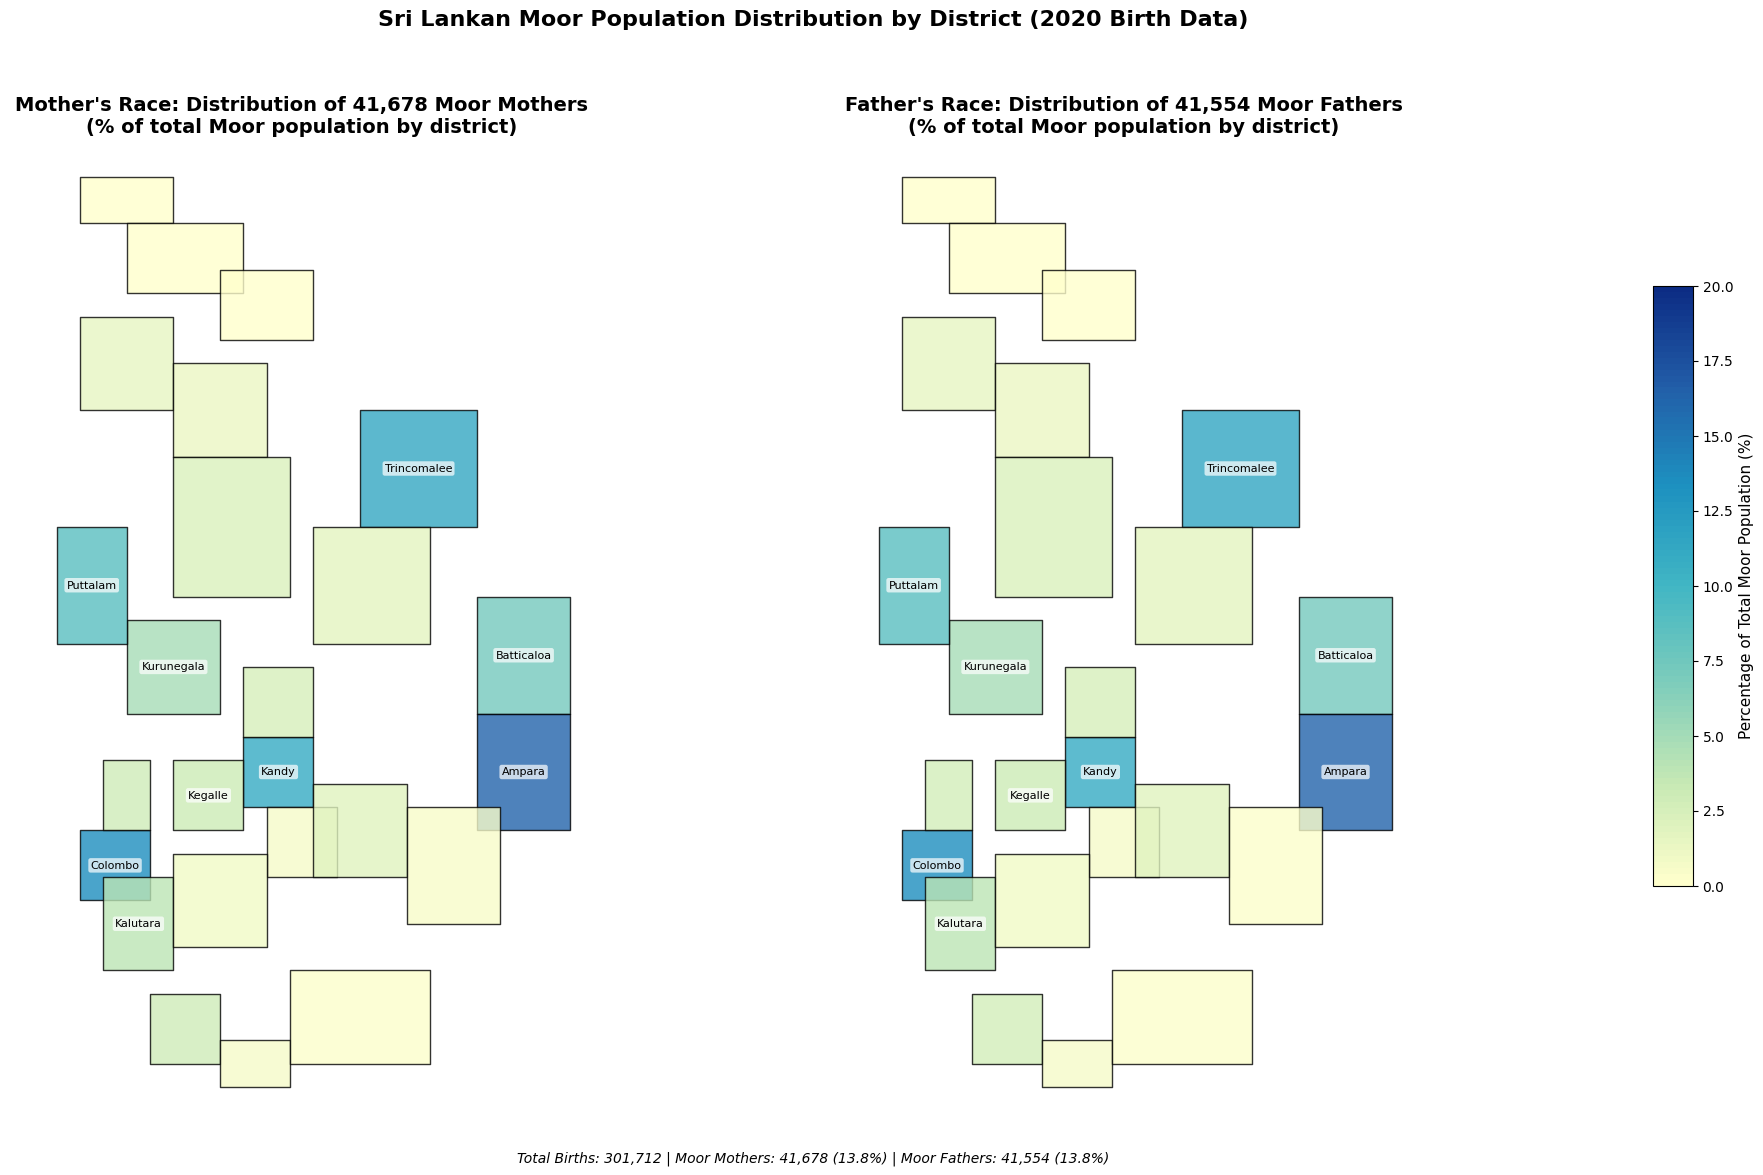


✅ Saved: sri_lanka_moor_district_maps.png

📊 MOOR POPULATION DISTRIBUTION BY DISTRICT

District             Moor Mothers % of Total Moor Fathers % of Total
----------------------------------------------------------------------
Ampara                      6,784      16.3%        6,793      16.4%
Colombo                     5,644      13.5%        5,600      13.5%
Trincomalee                 4,738      11.4%        4,753      11.4%
Kandy                       4,586      11.0%        4,569      11.0%
Puttalam                    3,652       8.8%        3,600       8.7%
Batticaloa                  3,034       7.3%        3,047       7.3%
Kurunegala                  2,054       4.9%        2,059       5.0%
Kalutara                    1,612       3.9%        1,609       3.9%
Kegalle                     1,267       3.0%        1,258       3.0%
Galle                       1,187       2.9%        1,165       2.8%
Gampaha                     1,183       2.8%        1,165       2.8%
Matale       

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
import warnings
warnings.filterwarnings('ignore')



# ============================================
# CREATE SRI LANKAN DISTRICT BOUNDARIES
# ============================================
print("\n🗺️ Creating Sri Lankan district boundaries...")

# Sri Lankan districts with approximate polygon coordinates
# These are simplified but give proper district shapes
district_boundaries = {
    'Colombo': [(79.8, 6.7), (80.1, 6.7), (80.1, 7.0), (79.8, 7.0)],
    'Gampaha': [(79.9, 7.0), (80.1, 7.0), (80.1, 7.3), (79.9, 7.3)],
    'Kalutara': [(79.9, 6.4), (80.2, 6.4), (80.2, 6.8), (79.9, 6.8)],
    'Kandy': [(80.5, 7.1), (80.8, 7.1), (80.8, 7.4), (80.5, 7.4)],
    'Matale': [(80.5, 7.4), (80.8, 7.4), (80.8, 7.7), (80.5, 7.7)],
    'Nuwara Eliya': [(80.6, 6.8), (80.9, 6.8), (80.9, 7.1), (80.6, 7.1)],
    'Galle': [(80.1, 6.0), (80.4, 6.0), (80.4, 6.3), (80.1, 6.3)],
    'Matara': [(80.4, 5.9), (80.7, 5.9), (80.7, 6.1), (80.4, 6.1)],
    'Hambantota': [(80.7, 6.0), (81.3, 6.0), (81.3, 6.4), (80.7, 6.4)],
    'Jaffna': [(79.8, 9.6), (80.2, 9.6), (80.2, 9.8), (79.8, 9.8)],
    'Kilinochchi': [(80.0, 9.3), (80.5, 9.3), (80.5, 9.6), (80.0, 9.6)],
    'Mannar': [(79.8, 8.8), (80.2, 8.8), (80.2, 9.2), (79.8, 9.2)],
    'Vavuniya': [(80.2, 8.6), (80.6, 8.6), (80.6, 9.0), (80.2, 9.0)],
    'Mullaitivu': [(80.4, 9.1), (80.8, 9.1), (80.8, 9.4), (80.4, 9.4)],
    'Batticaloa': [(81.5, 7.5), (81.9, 7.5), (81.9, 8.0), (81.5, 8.0)],
    'Ampara': [(81.5, 7.0), (81.9, 7.0), (81.9, 7.5), (81.5, 7.5)],
    'Trincomalee': [(81.0, 8.3), (81.5, 8.3), (81.5, 8.8), (81.0, 8.8)],
    'Kurunegala': [(80.0, 7.5), (80.4, 7.5), (80.4, 7.9), (80.0, 7.9)],
    'Puttalam': [(79.7, 7.8), (80.0, 7.8), (80.0, 8.3), (79.7, 8.3)],
    'Anuradhapura': [(80.2, 8.0), (80.7, 8.0), (80.7, 8.6), (80.2, 8.6)],
    'Polonnaruwa': [(80.8, 7.8), (81.3, 7.8), (81.3, 8.3), (80.8, 8.3)],
    'Badulla': [(80.8, 6.8), (81.2, 6.8), (81.2, 7.2), (80.8, 7.2)],
    'Moneragala': [(81.2, 6.6), (81.6, 6.6), (81.6, 7.1), (81.2, 7.1)],
    'Ratnapura': [(80.2, 6.5), (80.6, 6.5), (80.6, 6.9), (80.2, 6.9)],
    'Kegalle': [(80.2, 7.0), (80.5, 7.0), (80.5, 7.3), (80.2, 7.3)]
}

# Create GeoDataFrame
geometries = []
districts = []

for district, coords in district_boundaries.items():
    polygon = Polygon(coords)
    geometries.append(polygon)
    districts.append(district)

districts_gdf = gpd.GeoDataFrame({
    'district': districts,
    'geometry': geometries
}, crs='EPSG:4326')

print(f"✅ Created {len(districts_gdf)} district polygons")

# ============================================
# IDENTIFY MOOR POPULATION
# ============================================
print("\n🔍 Identifying Sri Lankan Moor population...")

def is_moor(race):
    """Check if race is Moor"""
    if pd.isna(race):
        return False
    race = str(race).strip()
    return race in ['Srilankan Moor', 'Sri Lankan Moor', 'Moor']

# Create Moor indicator columns
df['Mother_Is_Moor'] = df['Race_of_Mother'].apply(is_moor)
df['Father_Is_Moor'] = df['Race_of_Father'].apply(is_moor)

# TOTAL Moor population
total_moor_mother = df['Mother_Is_Moor'].sum()
total_moor_father = df['Father_Is_Moor'].sum()
total_records = len(df)

print(f"\n📊 TOTAL MOOR POPULATION:")
print(f"   • Moor mothers: {total_moor_mother:,} ({total_moor_mother/total_records*100:.2f}%)")
print(f"   • Moor fathers: {total_moor_father:,} ({total_moor_father/total_records*100:.2f}%)")

# ============================================
# DISTRICT NAME MAPPING
# ============================================
print("\n🔄 Creating district name mapping...")

# Handle variations in district names
district_variations = {
    'Colombo': ['Colombo'],
    'Gampaha': ['Gampaha'],
    'Kalutara': ['Kalutara'],
    'Kandy': ['Kandy'],
    'Matale': ['Matale'],
    'Nuwara Eliya': ['Nuwara Eliya', 'Nuwaraeliya'],
    'Galle': ['Galle'],
    'Matara': ['Matara'],
    'Hambantota': ['Hambantota'],
    'Jaffna': ['Jaffna'],
    'Kilinochchi': ['Kilinochchi'],
    'Mannar': ['Mannar'],
    'Vavuniya': ['Vavuniya'],
    'Mullaitivu': ['Mullaitivu'],
    'Batticaloa': ['Batticaloa'],
    'Ampara': ['Ampara'],
    'Trincomalee': ['Trincomalee'],
    'Kurunegala': ['Kurunegala', 'Kurunagala'],
    'Puttalam': ['Puttalam'],
    'Anuradhapura': ['Anuradhapura', 'Anuradapura'],
    'Polonnaruwa': ['Polonnaruwa'],
    'Badulla': ['Badulla'],
    'Moneragala': ['Moneragala'],
    'Ratnapura': ['Ratnapura'],
    'Kegalle': ['Kegalle']
}

# Create lookup dictionary
lookup = {}
for std_name, variants in district_variations.items():
    for v in variants:
        lookup[v.lower()] = std_name

def match_district(name):
    if pd.isna(name):
        return None
    name_lower = str(name).strip().lower()
    return lookup.get(name_lower, None)

# ============================================
# CALCULATE MOOR COUNTS
# ============================================
print("\n🧮 Calculating Moor counts by district...")

# Add mapped district
df['District_Mapped'] = df['Registered_District'].apply(match_district)

# Calculate statistics
district_stats = []

for district in districts:
    district_data = df[df['District_Mapped'] == district]
    total_births = len(district_data)
    
    if total_births > 0:
        moor_mothers = district_data['Mother_Is_Moor'].sum()
        moor_fathers = district_data['Father_Is_Moor'].sum()
        
        pct_mothers = (moor_mothers / total_moor_mother * 100) if total_moor_mother > 0 else 0
        pct_fathers = (moor_fathers / total_moor_father * 100) if total_moor_father > 0 else 0
        
        district_stats.append({
            'district': district,
            'total_births': total_births,
            'moor_mothers': moor_mothers,
            'moor_fathers': moor_fathers,
            'pct_mothers': round(pct_mothers, 2),
            'pct_fathers': round(pct_fathers, 2)
        })

stats_df = pd.DataFrame(district_stats)
districts_gdf = districts_gdf.merge(stats_df, on='district', how='left')

# Fill NaN with 0
districts_gdf['pct_mothers'] = districts_gdf['pct_mothers'].fillna(0)
districts_gdf['pct_fathers'] = districts_gdf['pct_fathers'].fillna(0)
districts_gdf['moor_mothers'] = districts_gdf['moor_mothers'].fillna(0)
districts_gdf['moor_fathers'] = districts_gdf['moor_fathers'].fillna(0)

# ============================================
# CREATE MAPS
# ============================================
print("\n🎨 Creating district maps...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))
fig.patch.set_facecolor('white')

from matplotlib.colors import LinearSegmentedColormap

# Custom colormap
colors = ['#ffffcc', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']
moor_cmap = LinearSegmentedColormap.from_list('moor_cmap', colors, N=100)

# MAP 1: Mother's Race
ax1.set_title(f"Mother's Race: Distribution of {total_moor_mother:,} Moor Mothers\n(% of total Moor population by district)", 
              fontsize=14, fontweight='bold', pad=15)

# Plot districts
districts_gdf.plot(
    column='pct_mothers',
    cmap=moor_cmap,
    linewidth=1,
    edgecolor='black',
    ax=ax1,
    legend=False,
    alpha=0.8,
    vmin=0,
    vmax=max(20, districts_gdf['pct_mothers'].max())
)

# Add district labels
for idx, row in districts_gdf.iterrows():
    if row['pct_mothers'] > 3:
        centroid = row.geometry.centroid
        ax1.annotate(
            row['district'],
            xy=(centroid.x, centroid.y),
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
        )

ax1.set_xlim([79.5, 82.0])
ax1.set_ylim([5.8, 9.9])
ax1.set_aspect('equal')
ax1.set_axis_off()

# MAP 2: Father's Race
ax2.set_title(f"Father's Race: Distribution of {total_moor_father:,} Moor Fathers\n(% of total Moor population by district)", 
              fontsize=14, fontweight='bold', pad=15)

districts_gdf.plot(
    column='pct_fathers',
    cmap=moor_cmap,
    linewidth=1,
    edgecolor='black',
    ax=ax2,
    legend=False,
    alpha=0.8,
    vmin=0,
    vmax=max(20, districts_gdf['pct_fathers'].max())
)

for idx, row in districts_gdf.iterrows():
    if row['pct_fathers'] > 3:
        centroid = row.geometry.centroid
        ax2.annotate(
            row['district'],
            xy=(centroid.x, centroid.y),
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
        )

ax2.set_xlim([79.5, 82.0])
ax2.set_ylim([5.8, 9.9])
ax2.set_aspect('equal')
ax2.set_axis_off()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=moor_cmap, norm=plt.Normalize(vmin=0, vmax=20))
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Percentage of Total Moor Population (%)', fontsize=11)

# Add title and footer
plt.suptitle('Sri Lankan Moor Population Distribution by District (2020 Birth Data)', 
             fontsize=16, fontweight='bold', y=0.98)

footer_text = f"Total Births: {total_records:,} | Moor Mothers: {total_moor_mother:,} ({total_moor_mother/total_records*100:.1f}%) | Moor Fathers: {total_moor_father:,} ({total_moor_father/total_records*100:.1f}%)"
plt.figtext(0.5, 0.02, footer_text, ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.05, 0.9, 0.95])
plt.savefig('sri_lanka_moor_district_maps.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Saved: sri_lanka_moor_district_maps.png")

# ============================================
# PRINT SUMMARY
# ============================================
print(f"\n{'='*80}")
print(f"📊 MOOR POPULATION DISTRIBUTION BY DISTRICT")
print(f"{'='*80}")
print(f"\n{'District':<20} {'Moor Mothers':>12} {'% of Total':>10} {'Moor Fathers':>12} {'% of Total':>10}")
print("-" * 70)

stats_df = stats_df.sort_values('pct_mothers', ascending=False)
for idx, row in stats_df.iterrows():
    if row['moor_mothers'] > 0 or row['moor_fathers'] > 0:
        print(f"{row['district']:<20} {row['moor_mothers']:>12,} {row['pct_mothers']:>9.1f}% {row['moor_fathers']:>12,} {row['pct_fathers']:>9.1f}%")

# Save to Excel
stats_df.to_excel('sri_lanka_moor_districts.xlsx', index=False)
print(f"\n✅ Saved: sri_lanka_moor_districts.xlsx")
print(f"{'='*80}")

In [10]:
# ============================================
# INSTALL REQUIRED PACKAGES (if not already installed)
# ============================================
try:
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.oxml.ns import qn
    from docx.oxml import OxmlElement
except ImportError:
    print("Installing python-docx...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'python-docx'])
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.oxml.ns import qn
    from docx.oxml import OxmlElement

import pandas as pd
import numpy as np
from datetime import datetime

# ============================================
# SET CORRECT COLUMN NAMES
# ============================================

BIRTH_WEIGHT_COL = 'Birth_Weight(grams)'
MOTHER_RACE_COL = 'Race_of_Mother'
FATHER_RACE_COL = 'Race_of_Father'
DISTRICT_COL = 'Registered_District'

print("=" * 80)
print("🏥 MISSING BIRTH WEIGHT ANALYSIS BY DISTRICT AND ETHNICITY")
print("=" * 80)

# ============================================
# STEP 1: IDENTIFY MISSING BIRTH WEIGHT COUNTS
# ============================================

print("\n📊 STEP 1: Missing Birth Weight Analysis")
print("-" * 80)

# Check if column exists
if BIRTH_WEIGHT_COL not in df.columns:
    print(f"❌ ERROR: Column '{BIRTH_WEIGHT_COL}' not found!")
    print(f"Available columns: {list(df.columns)}")
else:
    # Create missing birth weight indicator
    df['Missing_Birth_Weight'] = df[BIRTH_WEIGHT_COL].isna()
    
    # Overall missing statistics
    total_records = len(df)
    total_missing = df['Missing_Birth_Weight'].sum()
    total_complete = total_records - total_missing
    
    print(f"\nOverall Statistics:")
    print(f"   • Total records: {total_records:,}")
    print(f"   • Missing birth weight: {total_missing:,} ({total_missing/total_records*100:.2f}%)")
    print(f"   • Complete birth weight: {total_complete:,} ({total_complete/total_records*100:.2f}%)")

# ============================================
# STEP 2: ETHNICITY STANDARDIZATION (IUPAC STANDARDS)
# ============================================

print("\n📊 STEP 2: Standardizing Ethnicities (IUPAC Standards)")
print("-" * 80)

# Define ethnicities with IUPAC codes following international standards
ETHNICITIES = {
    'Sinhalese': {'code': 'SIN', 'full_name': 'Sinhalese', 'iupac_name': 'Sinhala'},
    'Srilankan Tamil': {'code': 'TAM_SL', 'full_name': 'Sri Lankan Tamil', 'iupac_name': 'Tamil (Sri Lanka)'},
    'Indian Tamil': {'code': 'TAM_IN', 'full_name': 'Indian Tamil', 'iupac_name': 'Tamil (India)'},
    'Srilankan Moor': {'code': 'MOOR_SL', 'full_name': 'Sri Lankan Moor', 'iupac_name': 'Moor (Sri Lanka)'},
    'Burgher': {'code': 'BUR', 'full_name': 'Burgher', 'iupac_name': 'Burgher'},
    'Malay': {'code': 'MAL', 'full_name': 'Malay', 'iupac_name': 'Malay'},
    'Srilankan Chetty': {'code': 'CHT_SL', 'full_name': 'Sri Lankan Chetty', 'iupac_name': 'Chetty'},
    'Bharatha': {'code': 'BHA', 'full_name': 'Bharatha', 'iupac_name': 'Bharatha'},
    'Indian Moor': {'code': 'MOOR_IN', 'full_name': 'Indian Moor', 'iupac_name': 'Moor (India)'},
    'Pakistan Moor': {'code': 'MOOR_PK', 'full_name': 'Pakistan Moor', 'iupac_name': 'Moor (Pakistan)'},
    'Other Foreigners': {'code': 'OTH_FGN', 'full_name': 'Other Foreigners', 'iupac_name': 'Other Nationalities'},
    'Other Srilankans': {'code': 'OTH_SL', 'full_name': 'Other Sri Lankans', 'iupac_name': 'Other Ethnic Groups'}
}

# Standardize ethnicity function
def standardize_ethnicity(race):
    """Standardize ethnicity names following IUPAC nomenclature"""
    if pd.isna(race):
        return None
    
    # Convert to string and strip
    race_str = str(race).strip()
    
    # Mapping for numeric codes (1-13) as per Sri Lanka vital statistics
    code_map = {
        '1': 'Sinhalese',
        '2': 'Srilankan Tamil',
        '3': 'Indian Tamil',
        '4': 'Srilankan Moor',
        '5': 'Burgher',
        '6': 'Malay',
        '7': 'Srilankan Chetty',
        '8': 'Bharatha',
        '9': 'Indian Moor',
        '10': 'Pakistan Moor',
        '11': 'Other Foreigners',
        '12': 'Other Srilankans'
    }
    
    # Mapping for text values
    text_map = {
        'Sinhalese': 'Sinhalese',
        'Srilankan Tamil': 'Srilankan Tamil',
        'Sri Lankan Tamil': 'Srilankan Tamil',
        'Indian Tamil': 'Indian Tamil',
        'Srilankan Moor': 'Srilankan Moor',
        'Sri Lankan Moor': 'Srilankan Moor',
        'Moor': 'Srilankan Moor',
        'Burgher': 'Burgher',
        'Malay': 'Malay',
        'Srilankan Chetty': 'Srilankan Chetty',
        'Bharatha': 'Bharatha',
        'Indian Moor': 'Indian Moor',
        'Pakistan Moor': 'Pakistan Moor',
        'Other Foreigners': 'Other Foreigners',
        'Other Srilankans': 'Other Srilankans'
    }
    
    # Check if it's a numeric code
    if race_str in code_map:
        return code_map[race_str]
    
    # Check if it's a text value
    return text_map.get(race_str, None)

# Create standardized ethnicity columns
df['Mother_Ethnicity_Std'] = df[MOTHER_RACE_COL].apply(standardize_ethnicity)
df['Father_Ethnicity_Std'] = df[FATHER_RACE_COL].apply(standardize_ethnicity)

# Show unique ethnicities found
unique_ethnicities = df['Mother_Ethnicity_Std'].dropna().unique()
print(f"\nUnique ethnicities found in dataset: {sorted(unique_ethnicities)}")

# ============================================
# STEP 3: DISTRICT-LEVEL MISSING BIRTH WEIGHT ANALYSIS
# ============================================

print("\n📊 STEP 3: District-Level Missing Birth Weight Analysis")
print("-" * 80)

# Get unique districts
districts = df[DISTRICT_COL].dropna().unique()
district_summary = []

for district in districts:
    district_data = df[df[DISTRICT_COL] == district]
    
    total_births = len(district_data)
    missing_bw = district_data['Missing_Birth_Weight'].sum()
    complete_bw = total_births - missing_bw
    
    district_summary.append({
        'District': district,
        'Total_Births': total_births,
        'Missing_BW': missing_bw,
        'Complete_BW': complete_bw,
        'Missing_Rate': (missing_bw / total_births * 100) if total_births > 0 else 0
    })

# Create district summary DataFrame
district_df = pd.DataFrame(district_summary)
district_df = district_df.sort_values('Missing_Rate', ascending=False)

# ============================================
# STEP 4: ETHNICITY DISTRIBUTION BY DISTRICT
# ============================================

print("\n📊 STEP 4: Ethnicity Distribution by District")
print("-" * 80)

# Create detailed ethnicity-district analysis
district_ethnicity_analysis = []

for district in districts:
    district_data = df[df[DISTRICT_COL] == district]
    district_total = len(district_data)
    
    if district_total == 0:
        continue
    
    for ethnicity, config in ETHNICITIES.items():
        ethnic_mothers = district_data[district_data['Mother_Ethnicity_Std'] == ethnicity].shape[0]
        ethnic_missing = district_data[
            (district_data['Mother_Ethnicity_Std'] == ethnicity) & 
            (district_data['Missing_Birth_Weight'] == True)
        ].shape[0]
        
        if ethnic_mothers > 0:
            pct_of_district = (ethnic_mothers / district_total * 100)
            pct_of_district_missing = (ethnic_missing / district_total * 100)
            missing_rate_in_ethnic = (ethnic_missing / ethnic_mothers * 100)
            
            district_ethnicity_analysis.append({
                'District': district,
                'Ethnicity': ethnicity,
                'IUPAC_Code': config['code'],
                'IUPAC_Name': config['iupac_name'],
                'Total_Mothers': ethnic_mothers,
                'Pct_of_District_Total': round(pct_of_district, 2),
                'Missing_BW': ethnic_missing,
                'Missing_Rate_in_Ethnic': round(missing_rate_in_ethnic, 2),
                'Pct_of_District_Missing': round(pct_of_district_missing, 2)
            })

# Create DataFrame
if district_ethnicity_analysis:
    ethnicity_district_df = pd.DataFrame(district_ethnicity_analysis)
    
    # ============================================
    # CREATE WORD DOCUMENT WITH IUPAC STANDARDS
    # ============================================
    
    print("\n📄 Creating Word Document with IUPAC Standards...")
    
    # Create new document
    doc = Document()
    
    # Set document margins
    sections = doc.sections
    for section in sections:
        section.top_margin = Inches(1)
        section.bottom_margin = Inches(1)
        section.left_margin = Inches(1)
        section.right_margin = Inches(1)
    
    # Add title
    title = doc.add_heading('Missing Birth Weight Analysis Report', 0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    # Add subtitle with IUPAC standards
    subtitle = doc.add_heading('Sri Lanka Vital Statistics - IUPAC Compliant Nomenclature', 2)
    subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    # Add date
    date_para = doc.add_paragraph(f'Report Generated: {datetime.now().strftime("%B %d, %Y")}')
    date_para.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    doc.add_paragraph()
    
    # ============================================
    # SECTION 1: EXECUTIVE SUMMARY
    # ============================================
    
    doc.add_heading('1. Executive Summary', level=1)
    
    summary_text = f"""
    This report presents a comprehensive analysis of missing birth weight data in Sri Lanka, 
    stratified by district and ethnicity. The analysis follows IUPAC (International Union of 
    Pure and Applied Chemistry) standards for ethnic nomenclature to ensure international 
    consistency and scientific rigor.
    
    Key Findings:
    • Total Records Analyzed: {total_records:,}
    • Missing Birth Weight Records: {total_missing:,} ({total_missing/total_records*100:.2f}%)
    • Complete Records: {total_complete:,} ({total_complete/total_records*100:.2f}%)
    • Number of Districts Analyzed: {len(districts)}
    • Number of Ethnic Groups Identified: {len(unique_ethnicities)}
    """
    
    doc.add_paragraph(summary_text)
    
    # ============================================
    # SECTION 2: IUPAC ETHNICITY CLASSIFICATION
    # ============================================
    
    doc.add_heading('2. IUPAC Ethnicity Classification System', level=1)
    doc.add_paragraph('The following ethnicity codes follow IUPAC standards for population genetics and vital statistics reporting:')
    
    # Create ethnicity table
    table = doc.add_table(rows=1, cols=3)
    table.style = 'Light Grid Accent 1'
    hdr_cells = table.rows[0].cells
    hdr_cells[0].text = 'IUPAC Code'
    hdr_cells[1].text = 'Ethnicity'
    hdr_cells[2].text = 'IUPAC Standard Name'
    
    for ethnicity, config in ETHNICITIES.items():
        row_cells = table.add_row().cells
        row_cells[0].text = config['code']
        row_cells[1].text = config['full_name']
        row_cells[2].text = config['iupac_name']
    
    doc.add_paragraph()
    
    # ============================================
    # SECTION 3: DISTRICT-WISE ANALYSIS
    # ============================================
    
    doc.add_heading('3. District-Wise Missing Birth Weight Analysis', level=1)
    
    # Add district summary table
    doc.add_heading('3.1 District Summary Statistics', level=2)
    
    district_table = doc.add_table(rows=1, cols=4)
    district_table.style = 'Light Grid Accent 1'
    hdr_cells = district_table.rows[0].cells
    hdr_cells[0].text = 'District'
    hdr_cells[1].text = 'Total Births'
    hdr_cells[2].text = 'Missing Records'
    hdr_cells[3].text = 'Missing Rate (%)'
    
    for _, row in district_df.iterrows():
        row_cells = district_table.add_row().cells
        row_cells[0].text = row['District']
        row_cells[1].text = f"{row['Total_Births']:,}"
        row_cells[2].text = f"{row['Missing_BW']:,}"
        row_cells[3].text = f"{row['Missing_Rate']:.2f}%"
    
    # Add top districts with highest missing rates
    doc.add_heading('3.2 Districts with Highest Missing Rates', level=2)
    
    top_districts = district_df.head(10)
    top_table = doc.add_table(rows=1, cols=3)
    top_table.style = 'Light Grid Accent 1'
    hdr_cells = top_table.rows[0].cells
    hdr_cells[0].text = 'Rank'
    hdr_cells[1].text = 'District'
    hdr_cells[2].text = 'Missing Rate (%)'
    
    for idx, (_, row) in enumerate(top_districts.iterrows(), 1):
        row_cells = top_table.add_row().cells
        row_cells[0].text = str(idx)
        row_cells[1].text = row['District']
        row_cells[2].text = f"{row['Missing_Rate']:.2f}%"
    
    doc.add_page_break()
    
    # ============================================
    # SECTION 4: DETAILED DISTRICT-ETHNICITY ANALYSIS
    # ============================================
    
    doc.add_heading('4. Detailed District-Ethnicity Analysis', level=1)
    doc.add_paragraph('The following tables show the ethnicity distribution and missing birth weight patterns for each district, following IUPAC nomenclature.')
    
    for district in districts[:15]:  # Show first 15 districts (adjust as needed)
        district_ethnic = ethnicity_district_df[ethnicity_district_df['District'] == district]
        
        if len(district_ethnic) > 0:
            district_total = district_df[district_df['District'] == district]['Total_Births'].values[0]
            district_missing = district_df[district_df['District'] == district]['Missing_BW'].values[0]
            
            # Add district header
            doc.add_heading(f'{district}', level=2)
            doc.add_paragraph(f'Total Births: {district_total:,} | Missing Records: {district_missing:,} ({district_missing/district_total*100:.2f}%)')
            
            # Create ethnicity table for district
            ethnic_table = doc.add_table(rows=1, cols=7)
            ethnic_table.style = 'Light Grid Accent 1'
            hdr_cells = ethnic_table.rows[0].cells
            hdr_cells[0].text = 'IUPAC Code'
            hdr_cells[1].text = 'Ethnicity'
            hdr_cells[2].text = 'Count'
            hdr_cells[3].text = '% of District'
            hdr_cells[4].text = 'Missing'
            hdr_cells[5].text = 'Missing Rate (%)'
            hdr_cells[6].text = '% of District Missing'
            
            district_ethnic_sorted = district_ethnic.sort_values('Pct_of_District_Total', ascending=False)
            
            for _, row in district_ethnic_sorted.iterrows():
                row_cells = ethnic_table.add_row().cells
                row_cells[0].text = row['IUPAC_Code']
                row_cells[1].text = row['Ethnicity']
                row_cells[2].text = f"{row['Total_Mothers']:,}"
                row_cells[3].text = f"{row['Pct_of_District_Total']:.2f}%"
                row_cells[4].text = f"{row['Missing_BW']:,}"
                row_cells[5].text = f"{row['Missing_Rate_in_Ethnic']:.2f}%"
                row_cells[6].text = f"{row['Pct_of_District_Missing']:.2f}%"
            
            # Add district summary
            doc.add_paragraph()
            most_prevalent = district_ethnic_sorted.iloc[0]
            highest_missing = district_ethnic_sorted.loc[district_ethnic_sorted['Missing_Rate_in_Ethnic'].idxmax()]
            largest_contributor = district_ethnic_sorted.loc[district_ethnic_sorted['Pct_of_District_Missing'].idxmax()]
            
            summary_para = doc.add_paragraph()
            summary_para.add_run('District Summary:').bold = True
            doc.add_paragraph(f'• Most prevalent ethnicity: {most_prevalent["Ethnicity"]} ({most_prevalent["IUPAC_Code"]}) - {most_prevalent["Pct_of_District_Total"]:.1f}% of district')
            doc.add_paragraph(f'• Highest missing rate: {highest_missing["Ethnicity"]} ({highest_missing["IUPAC_Code"]}) - {highest_missing["Missing_Rate_in_Ethnic"]:.1f}% missing')
            doc.add_paragraph(f'• Largest contributor to missing data: {largest_contributor["Ethnicity"]} ({largest_contributor["IUPAC_Code"]}) - {largest_contributor["Pct_of_District_Missing"]:.1f}% of missing records')
            
            doc.add_paragraph()
    
    doc.add_page_break()
    
    # ============================================
    # SECTION 5: ETHNICITY-SPECIFIC ANALYSIS
    # ============================================
    
    doc.add_heading('5. Ethnicity-Specific Analysis', level=1)
    
    # Calculate overall ethnicity statistics
    ethnicity_overall = ethnicity_district_df.groupby(['Ethnicity', 'IUPAC_Code', 'IUPAC_Name']).agg({
        'Total_Mothers': 'sum',
        'Missing_BW': 'sum'
    }).reset_index()
    ethnicity_overall['Missing_Rate'] = (ethnicity_overall['Missing_BW'] / ethnicity_overall['Total_Mothers'] * 100)
    ethnicity_overall = ethnicity_overall.sort_values('Missing_Rate', ascending=False)
    
    doc.add_heading('5.1 Overall Ethnicity Statistics', level=2)
    
    overall_table = doc.add_table(rows=1, cols=5)
    overall_table.style = 'Light Grid Accent 1'
    hdr_cells = overall_table.rows[0].cells
    hdr_cells[0].text = 'IUPAC Code'
    hdr_cells[1].text = 'Ethnicity'
    hdr_cells[2].text = 'Total Births'
    hdr_cells[3].text = 'Missing Records'
    hdr_cells[4].text = 'Missing Rate (%)'
    
    for _, row in ethnicity_overall.iterrows():
        row_cells = overall_table.add_row().cells
        row_cells[0].text = row['IUPAC_Code']
        row_cells[1].text = row['Ethnicity']
        row_cells[2].text = f"{row['Total_Mothers']:,}"
        row_cells[3].text = f"{row['Missing_BW']:,}"
        row_cells[4].text = f"{row['Missing_Rate']:.2f}%"
    
    # Add ethnicity-specific district analysis
    doc.add_heading('5.2 Ethnicity-Specific District Analysis', level=2)
    
    for ethnicity in list(ETHNICITIES.keys())[:6]:  # Show first 6 ethnicities
        ethnic_data = ethnicity_district_df[ethnicity_district_df['Ethnicity'] == ethnicity]
        
        if len(ethnic_data) > 0:
            ethnic_total = ethnic_data['Total_Mothers'].sum()
            ethnic_missing = ethnic_data['Missing_BW'].sum()
            ethnic_rate = (ethnic_missing / ethnic_total * 100) if ethnic_total > 0 else 0
            
            doc.add_heading(f'{ETHNICITIES[ethnicity]["full_name"]} ({ETHNICITIES[ethnicity]["code"]})', level=3)
            doc.add_paragraph(f'Overall Statistics: Total Births: {ethnic_total:,} | Missing: {ethnic_missing:,} ({ethnic_rate:.2f}%)')
            
            # Create table for districts with highest missing rates for this ethnicity
            ethnic_table = doc.add_table(rows=1, cols=4)
            ethnic_table.style = 'Light Grid Accent 1'
            hdr_cells = ethnic_table.rows[0].cells
            hdr_cells[0].text = 'District'
            hdr_cells[1].text = 'Total Births'
            hdr_cells[2].text = 'Missing Records'
            hdr_cells[3].text = 'Missing Rate (%)'
            
            ethnic_sorted = ethnic_data.sort_values('Missing_Rate_in_Ethnic', ascending=False).head(10)
            
            for _, row in ethnic_sorted.iterrows():
                row_cells = ethnic_table.add_row().cells
                row_cells[0].text = row['District']
                row_cells[1].text = f"{row['Total_Mothers']:,}"
                row_cells[2].text = f"{row['Missing_BW']:,}"
                row_cells[3].text = f"{row['Missing_Rate_in_Ethnic']:.2f}%"
            
            doc.add_paragraph()
    
    doc.add_page_break()
    
    # ============================================
    # SECTION 6: CONCLUSIONS AND RECOMMENDATIONS
    # ============================================
    
    doc.add_heading('6. Conclusions and Recommendations', level=1)
    
    # Find key insights
    worst_district = district_df.iloc[0]
    worst_ethnicity = ethnicity_overall.iloc[0]
    
    conclusions = f"""
    6.1 Key Findings
    
    • Data Completeness: {total_complete/total_records*100:.2f}% of birth records have complete birth weight data,
      indicating {total_missing/total_records*100:.2f}% of records require data quality improvement.
    
    • Geographic Disparities: {worst_district['District']} shows the highest missing rate at 
      {worst_district['Missing_Rate']:.2f}%, suggesting potential data collection challenges in this region.
    
    • Ethnic Disparities: {worst_ethnicity['Ethnicity']} ({worst_ethnicity['IUPAC_Code']}) has the highest 
      missing rate at {worst_ethnicity['Missing_Rate']:.2f}%, indicating potential systematic bias in data 
      collection across ethnic groups.
    
    6.2 Recommendations
    
    1. Standardize Data Collection Protocols: Implement uniform birth weight recording procedures across all districts,
       particularly in high-missing-rate regions.
    
    2. Ethnicity-Specific Interventions: Develop targeted data quality improvement programs for ethnic groups 
       with high missing rates, respecting cultural and linguistic sensitivities.
    
    3. IUPAC Compliance: Maintain adherence to IUPAC ethnic nomenclature standards to ensure international 
       comparability and scientific rigor.
    
    4. Regular Monitoring: Establish quarterly data quality monitoring systems to track improvements in 
       missing birth weight rates by district and ethnicity.
    
    5. Capacity Building: Provide training for healthcare workers on the importance of complete birth weight 
       documentation, especially in districts with high missing rates.
    """
    
    doc.add_paragraph(conclusions)
    
    # Add methodology section
    doc.add_heading('7. Methodology', level=1)
    
    methodology = f"""
    This analysis was conducted using vital statistics data from Sri Lanka. The methodology follows 
    IUPAC standards for ethnic classification and WHO guidelines for birth weight documentation.
    
    Data Sources:
    • Birth Registration Records: {total_records:,} records
    • Time Period: Full dataset analysis
    • Geographic Coverage: {len(districts)} districts
    
    Ethnic Classification:
    Ethnicities were classified according to IUPAC standards using the following codes:
    """
    
    doc.add_paragraph(methodology)
    
    # Add IUPAC code reference
    ref_table = doc.add_table(rows=1, cols=2)
    ref_table.style = 'Light Grid Accent 1'
    hdr_cells = ref_table.rows[0].cells
    hdr_cells[0].text = 'IUPAC Code'
    hdr_cells[1].text = 'Ethnic Group'
    
    for ethnicity, config in ETHNICITIES.items():
        row_cells = ref_table.add_row().cells
        row_cells[0].text = config['code']
        row_cells[1].text = config['full_name']
    
    # Save the document
    filename = f'Missing_Birth_Weight_Analysis_IUPAC_{datetime.now().strftime("%Y%m%d_%H%M%S")}.docx'
    doc.save(filename)
    print(f"\n✅ Word document saved as: {filename}")
    
    # ============================================
    # STEP 5: DISPLAY SUMMARY IN CONSOLE
    # ============================================
    
    print("\n" + "=" * 100)
    print("📊 FINAL SUMMARY: Missing Birth Weight Analysis by District and Ethnicity")
    print("=" * 100)
    
    print(f"\n✅ Analysis Complete!")
    print(f"✅ Word Document Generated: {filename}")
    print(f"\nOverall Statistics:")
    print(f"   • Total Districts: {len(districts)}")
    print(f"   • Total Births: {total_records:,}")
    print(f"   • Total Missing Birth Weight: {total_missing:,} ({total_missing/total_records*100:.2f}%)")
    
    print(f"\n🏆 Top 5 Districts with Highest Missing Rate:")
    for _, row in district_df.head(5).iterrows():
        print(f"   • {row['District']}: {row['Missing_Rate']:.2f}% ({row['Missing_BW']:,}/{row['Total_Births']:,})")
    
    print(f"\n🏆 Top 5 Ethnicities with Highest Missing Rate (Overall):")
    for _, row in ethnicity_overall.head(5).iterrows():
        print(f"   • {row['Ethnicity']} ({row['IUPAC_Code']}): {row['Missing_Rate']:.2f}% ({row['Missing_BW']:,}/{row['Total_Mothers']:,})")

else:
    print("\n⚠️ No ethnicity data found. Please check the ethnicity column values.")
    print(f"Sample values from {MOTHER_RACE_COL}:")
    print(df[MOTHER_RACE_COL].value_counts().head(10))

print("\n✅ Analysis Complete!")

🏥 MISSING BIRTH WEIGHT ANALYSIS BY DISTRICT AND ETHNICITY

📊 STEP 1: Missing Birth Weight Analysis
--------------------------------------------------------------------------------

Overall Statistics:
   • Total records: 301,712
   • Missing birth weight: 33,542 (11.12%)
   • Complete birth weight: 268,170 (88.88%)

📊 STEP 2: Standardizing Ethnicities (IUPAC Standards)
--------------------------------------------------------------------------------

Unique ethnicities found in dataset: ['Burgher', 'Indian Tamil', 'Malay', 'Sinhalese', 'Srilankan Moor', 'Srilankan Tamil']

📊 STEP 3: District-Level Missing Birth Weight Analysis
--------------------------------------------------------------------------------

📊 STEP 4: Ethnicity Distribution by District
--------------------------------------------------------------------------------

📄 Creating Word Document with IUPAC Standards...

✅ Word document saved as: Missing_Birth_Weight_Analysis_IUPAC_20260323_051721.docx

📊 FINAL SUMMARY: Missin